In [1]:
from transformers import AutoTokenizer, AutoModel
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import copy

c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
all_party_textes_df = pd.read_parquet("all_parties_text_combined_prep_classified.parquet")
labled_theses_df = pd.read_parquet('wahlomat_thesen_prep.parquet')
Labled_theses_classification_df = pd.read_parquet('wahlomaten_thesen_positionen_classified.parquet')

labled_theses_df['Predicted_Class'] = Labled_theses_classification_df['Predicted_Class']
del Labled_theses_classification_df


In [3]:
print(all_party_textes_df.columns)
print(labled_theses_df.columns)

Index(['Party', 'Chapter', 'These', 'Text', 'Text_no_stopwords',
       'These_no_stopwords', 'Text_lemmatized', 'These_lemmatized',
       'These_unique_words', 'These_Word_Count', 'Text_Word_Count',
       'Total_Word_Count', 'Predicted_Class'],
      dtype='object')
Index(['These', 'These_no_stopwords', 'These_lemmatized', 'These_unique_words',
       'CDU / CSU', 'GRÜNE', 'SPD', 'AfD', 'Die Linke', 'FDP',
       'Predicted_Class'],
      dtype='object')


In [4]:
lable_colums_list = labled_theses_df.columns[1:].tolist()

replace_dict = {
    'spd'   :   'SPD', 
    'cdu'   :   'CDU / CSU', 
    'gruene':   'GRÜNE', 
    'afd'   :   'AfD',
    'fdp'   :   'FDP', 
    'linke' :   'Die Linke'
}

all_party_textes_df['Party'] = all_party_textes_df['Party'].replace(replace_dict)
del replace_dict

In [ ]:
# Load tokenizer and model
model_name = "mmmaurer/sbert-hashtag-german-politicians-2021"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
tokenizer, model


def get_embedding(text:str, tokenizer: AutoTokenizer, model:AutoModel, pooling_method:str = 'mean'):
    # Tokenize the input
    inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt")

    # Get model output (embeddings)
    outputs = model(**inputs)

    # Extract the embeddings from the model output
    match pooling_method:
        case 'mean':
            return outputs.last_hidden_state.mean(dim=1).squeeze().detach().numpy()
        case 'max':
            return outputs.last_hidden_state.max(dim=1).values.squeeze().detach().numpy()
        case _:
            raise ValueError(f'The used pooling method ({pooling_method}) is not supported. Use "mean" or "max".')




In [ ]:
#(all_party_textes_df:pd.DataFrame, labled_theses_df:pd.DataFrame, content:str = 'These', plot:bool = False)
def similarity_func(all_party_textes_df:pd.DataFrame, 
                    labled_theses_df:pd.DataFrame, 
                    lable_text_column:str, 
                    party_text_column:str,
                    plot:bool = False, 
                    sort_by_classification:bool = False, 
                    pooling_method:str='mean'):
    
    # Liste der Parteien und Thesen
    all_party_textes_df['Chapter'] = all_party_textes_df['Chapter'].fillna('-')
    parties_list = all_party_textes_df['Party'].unique().tolist()
    predicted_theses_df = copy.deepcopy(labled_theses_df)
    
    labled_text_list = labled_theses_df[lable_text_column].tolist()
    predicted_theses_dfs_dict = {}

    # Schleife über die Parteien
    for party_str in parties_list:
        # Filtern der Daten für die aktuelle Partei
        party_df = all_party_textes_df[all_party_textes_df['Party'] == party_str]

        # Entfernen von Zeilen mit NaN-Werten
        party_df = party_df.dropna()

        # Extrahieren der Thesen für die aktuelle Partei
        party_text_list = party_df[party_text_column].to_list()

        # Erstellung eines DataFrames zur Berechnung der Ähnlichkeiten
        similarity_df = pd.DataFrame(columns=['party_text'] + labled_text_list)

        # Berechnung der Ähnlichkeit für jede Partei-These
        for party_text in party_text_list:
            party_text_embedding = get_embedding(party_text, tokenizer, model, pooling_method = pooling_method)
            row = [party_text]
            party_domain_num = party_df[party_df[party_text_column]==party_text]['Predicted_Class'].str[0].values[0]
            # Berechnung der Kosinusähnlichkeit für jede labelte These
            for label_text in labled_text_list:
                lable_domain_num = labled_theses_df[labled_theses_df[lable_text_column]==label_text]['Predicted_Class'].str[0].values[0] #labled_theses_df[lable_text_column]
                label_text_embedding = get_embedding(label_text,tokenizer, model, pooling_method = pooling_method)
                similarity_score = (cosine_similarity(party_text_embedding.reshape(1, -1), label_text_embedding.reshape(1, -1))[0][0])
                if lable_domain_num != party_domain_num and sort_by_classification:
                    similarity_score = 0
                row.append(similarity_score)

            similarity_df.loc[len(similarity_df)] = row

        if plot:
            # Visualisierung der Ähnlichkeiten als Heatmap
            plt.figure(figsize=(18, 18))
            sns.heatmap(similarity_df[labled_text_list],
                        cmap='RdYlGn',
                        annot=False,
                        vmax=1,
                        vmin=0,
                        yticklabels=party_df["These"])
            plt.xticks(rotation=45, ha="right")
            plt.title(f"Thesen-Heatmap: {party_str}")
            plt.show()

        # Maximale Ähnlichkeit für jede Partei
        predicted_theses_dfs_dict[party_str] = similarity_df
        predicted_theses_df[party_str] = similarity_df[labled_text_list].max().tolist()

    return predicted_theses_dfs_dict, predicted_theses_df
    
   

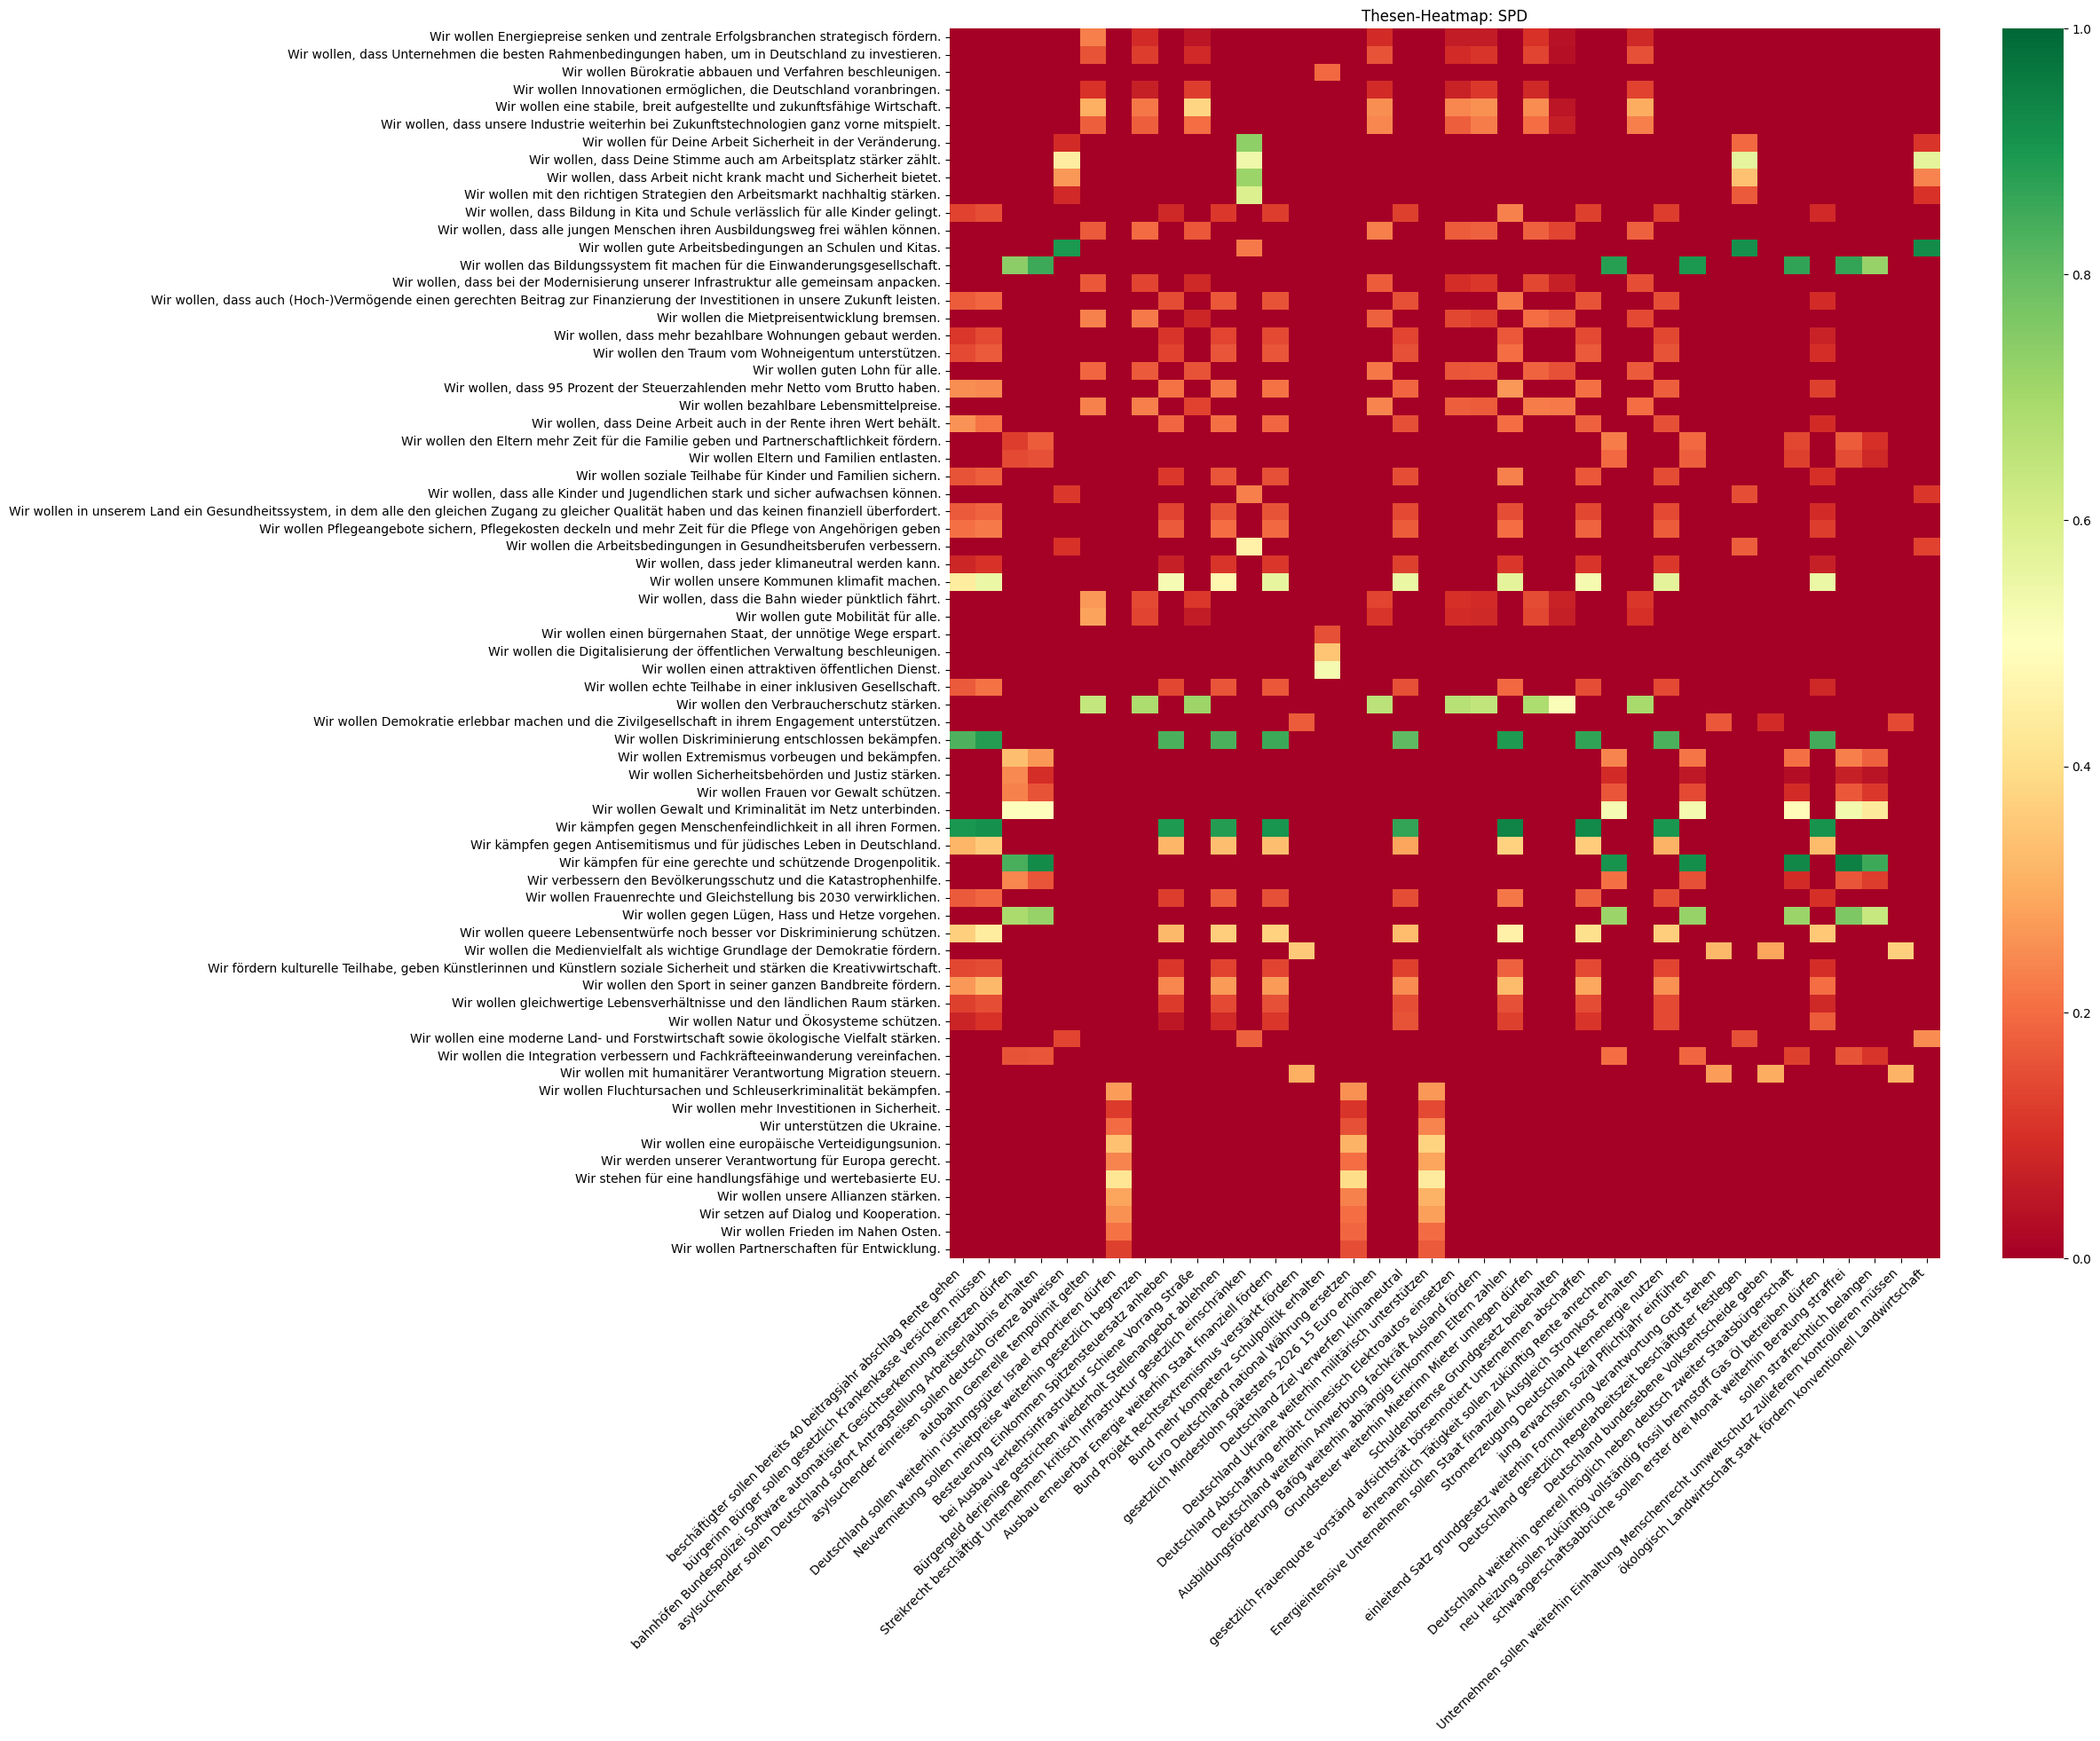

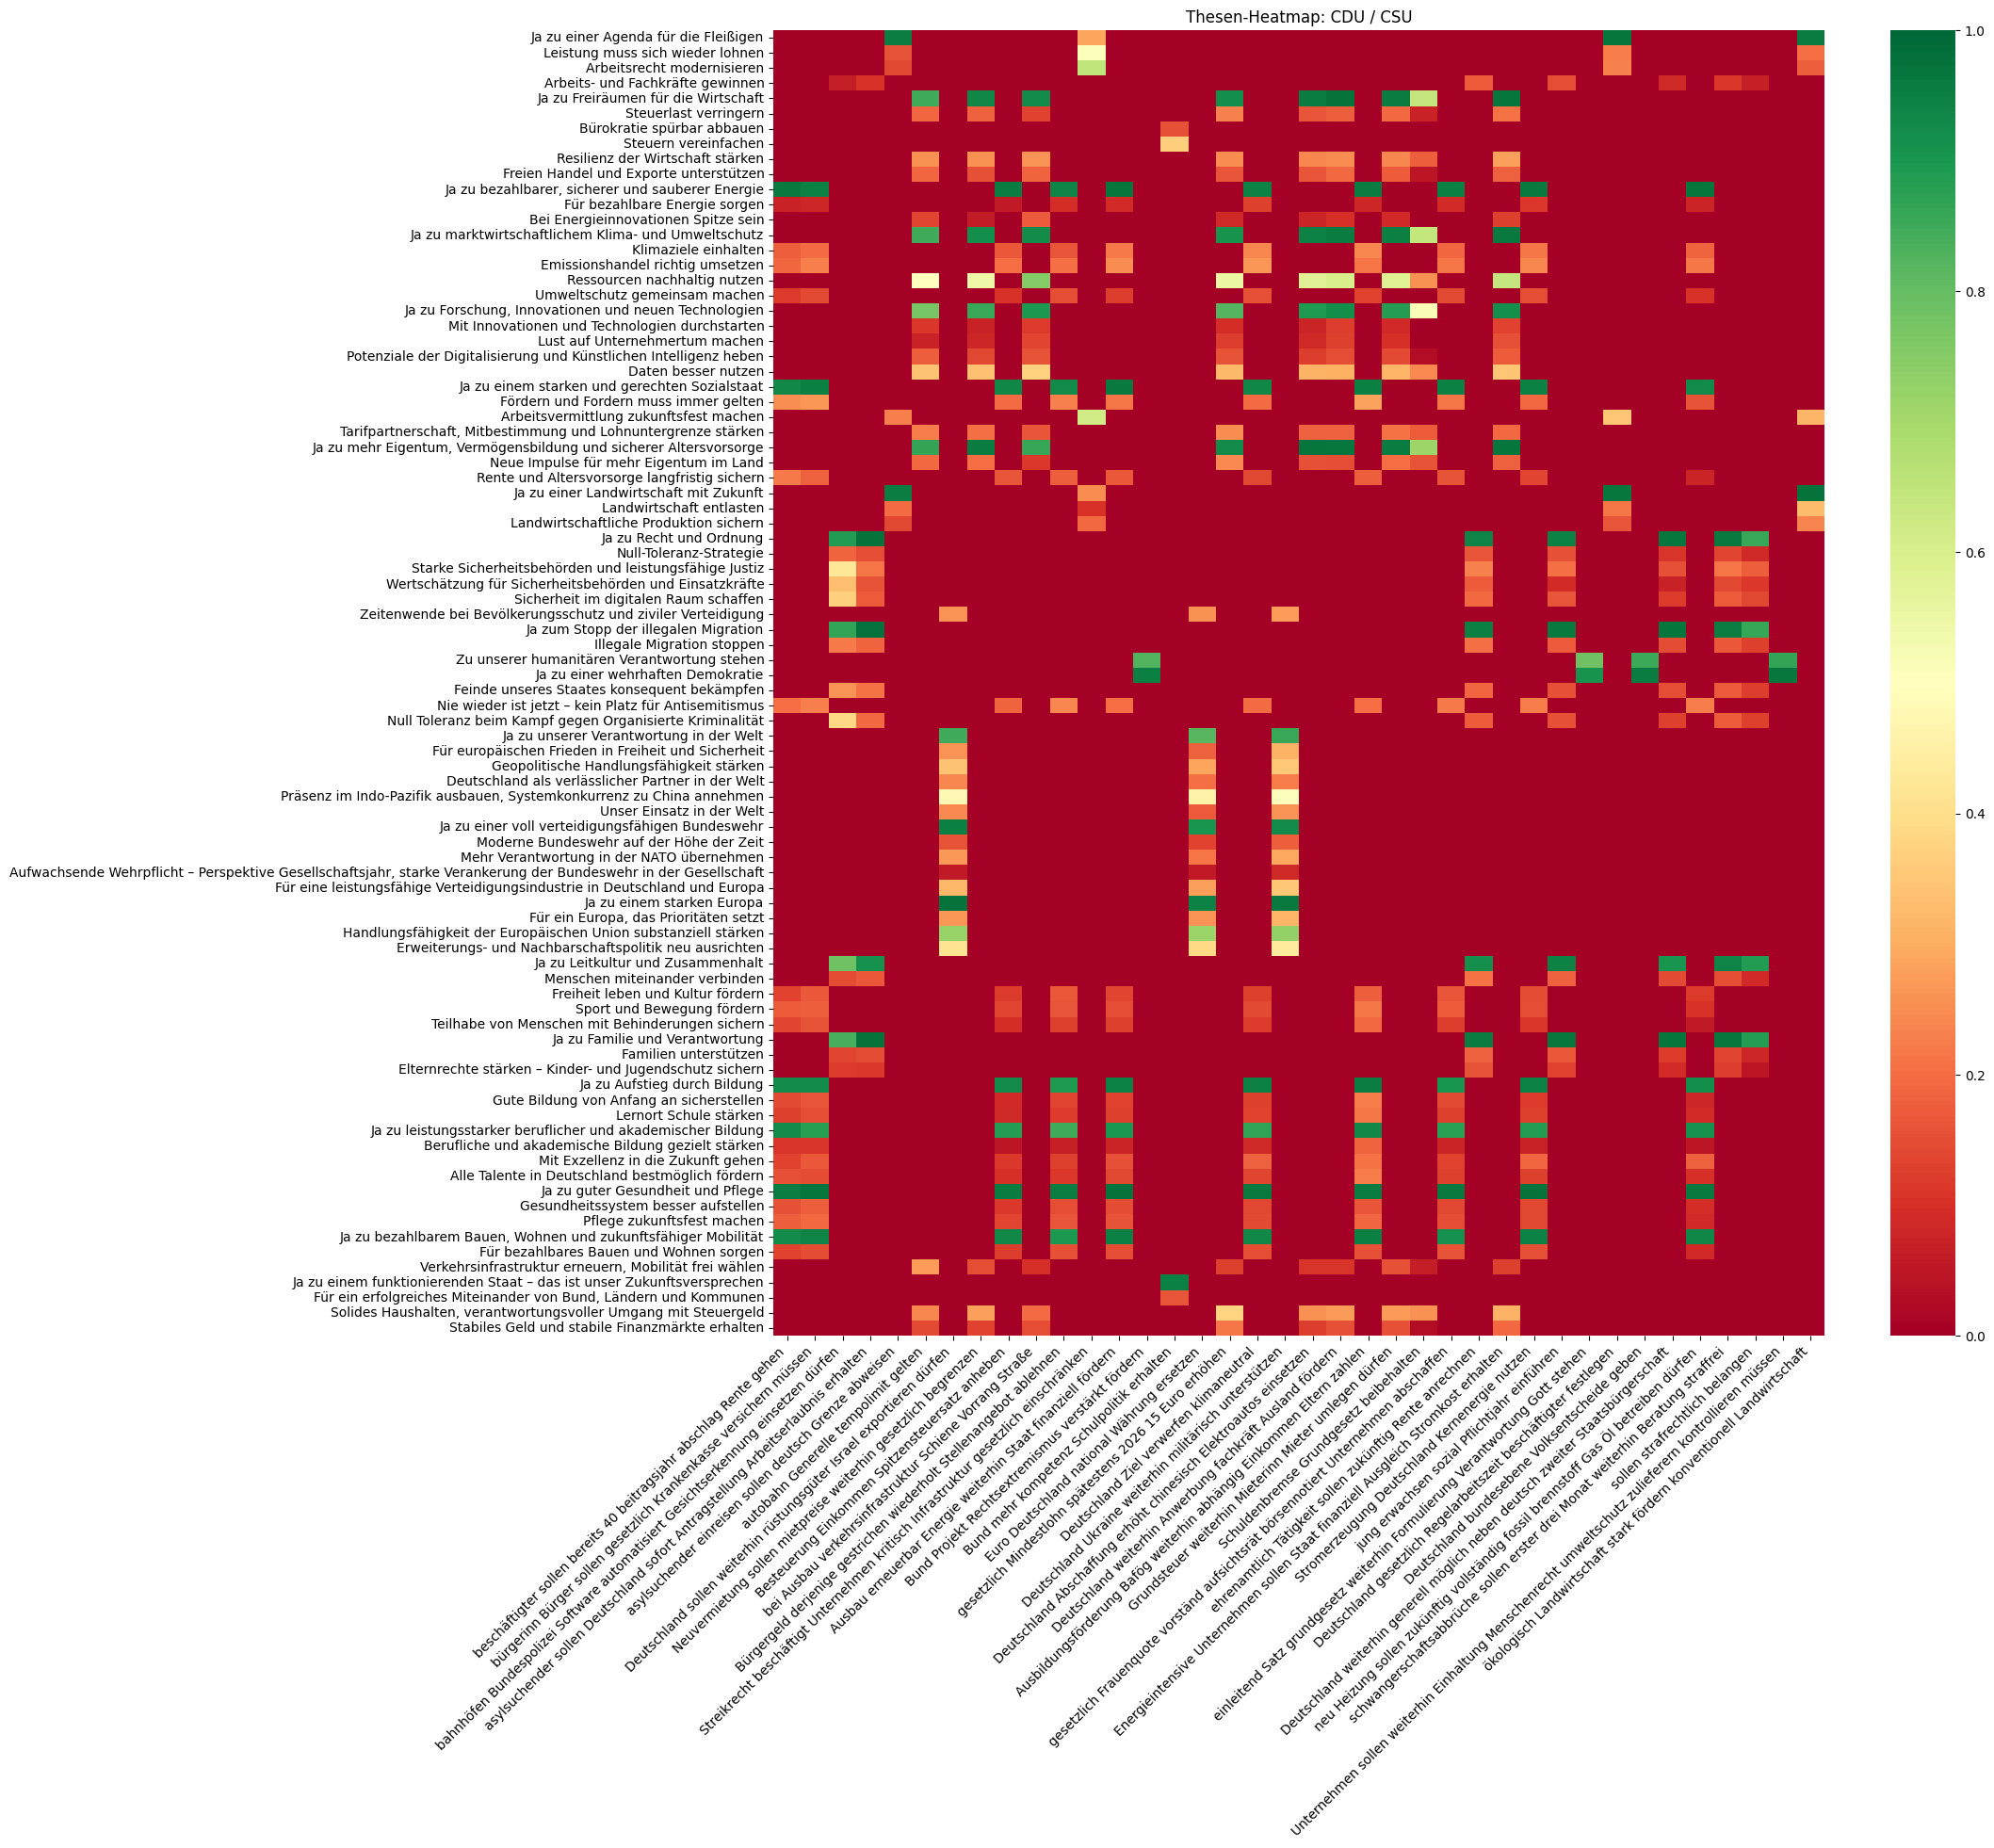

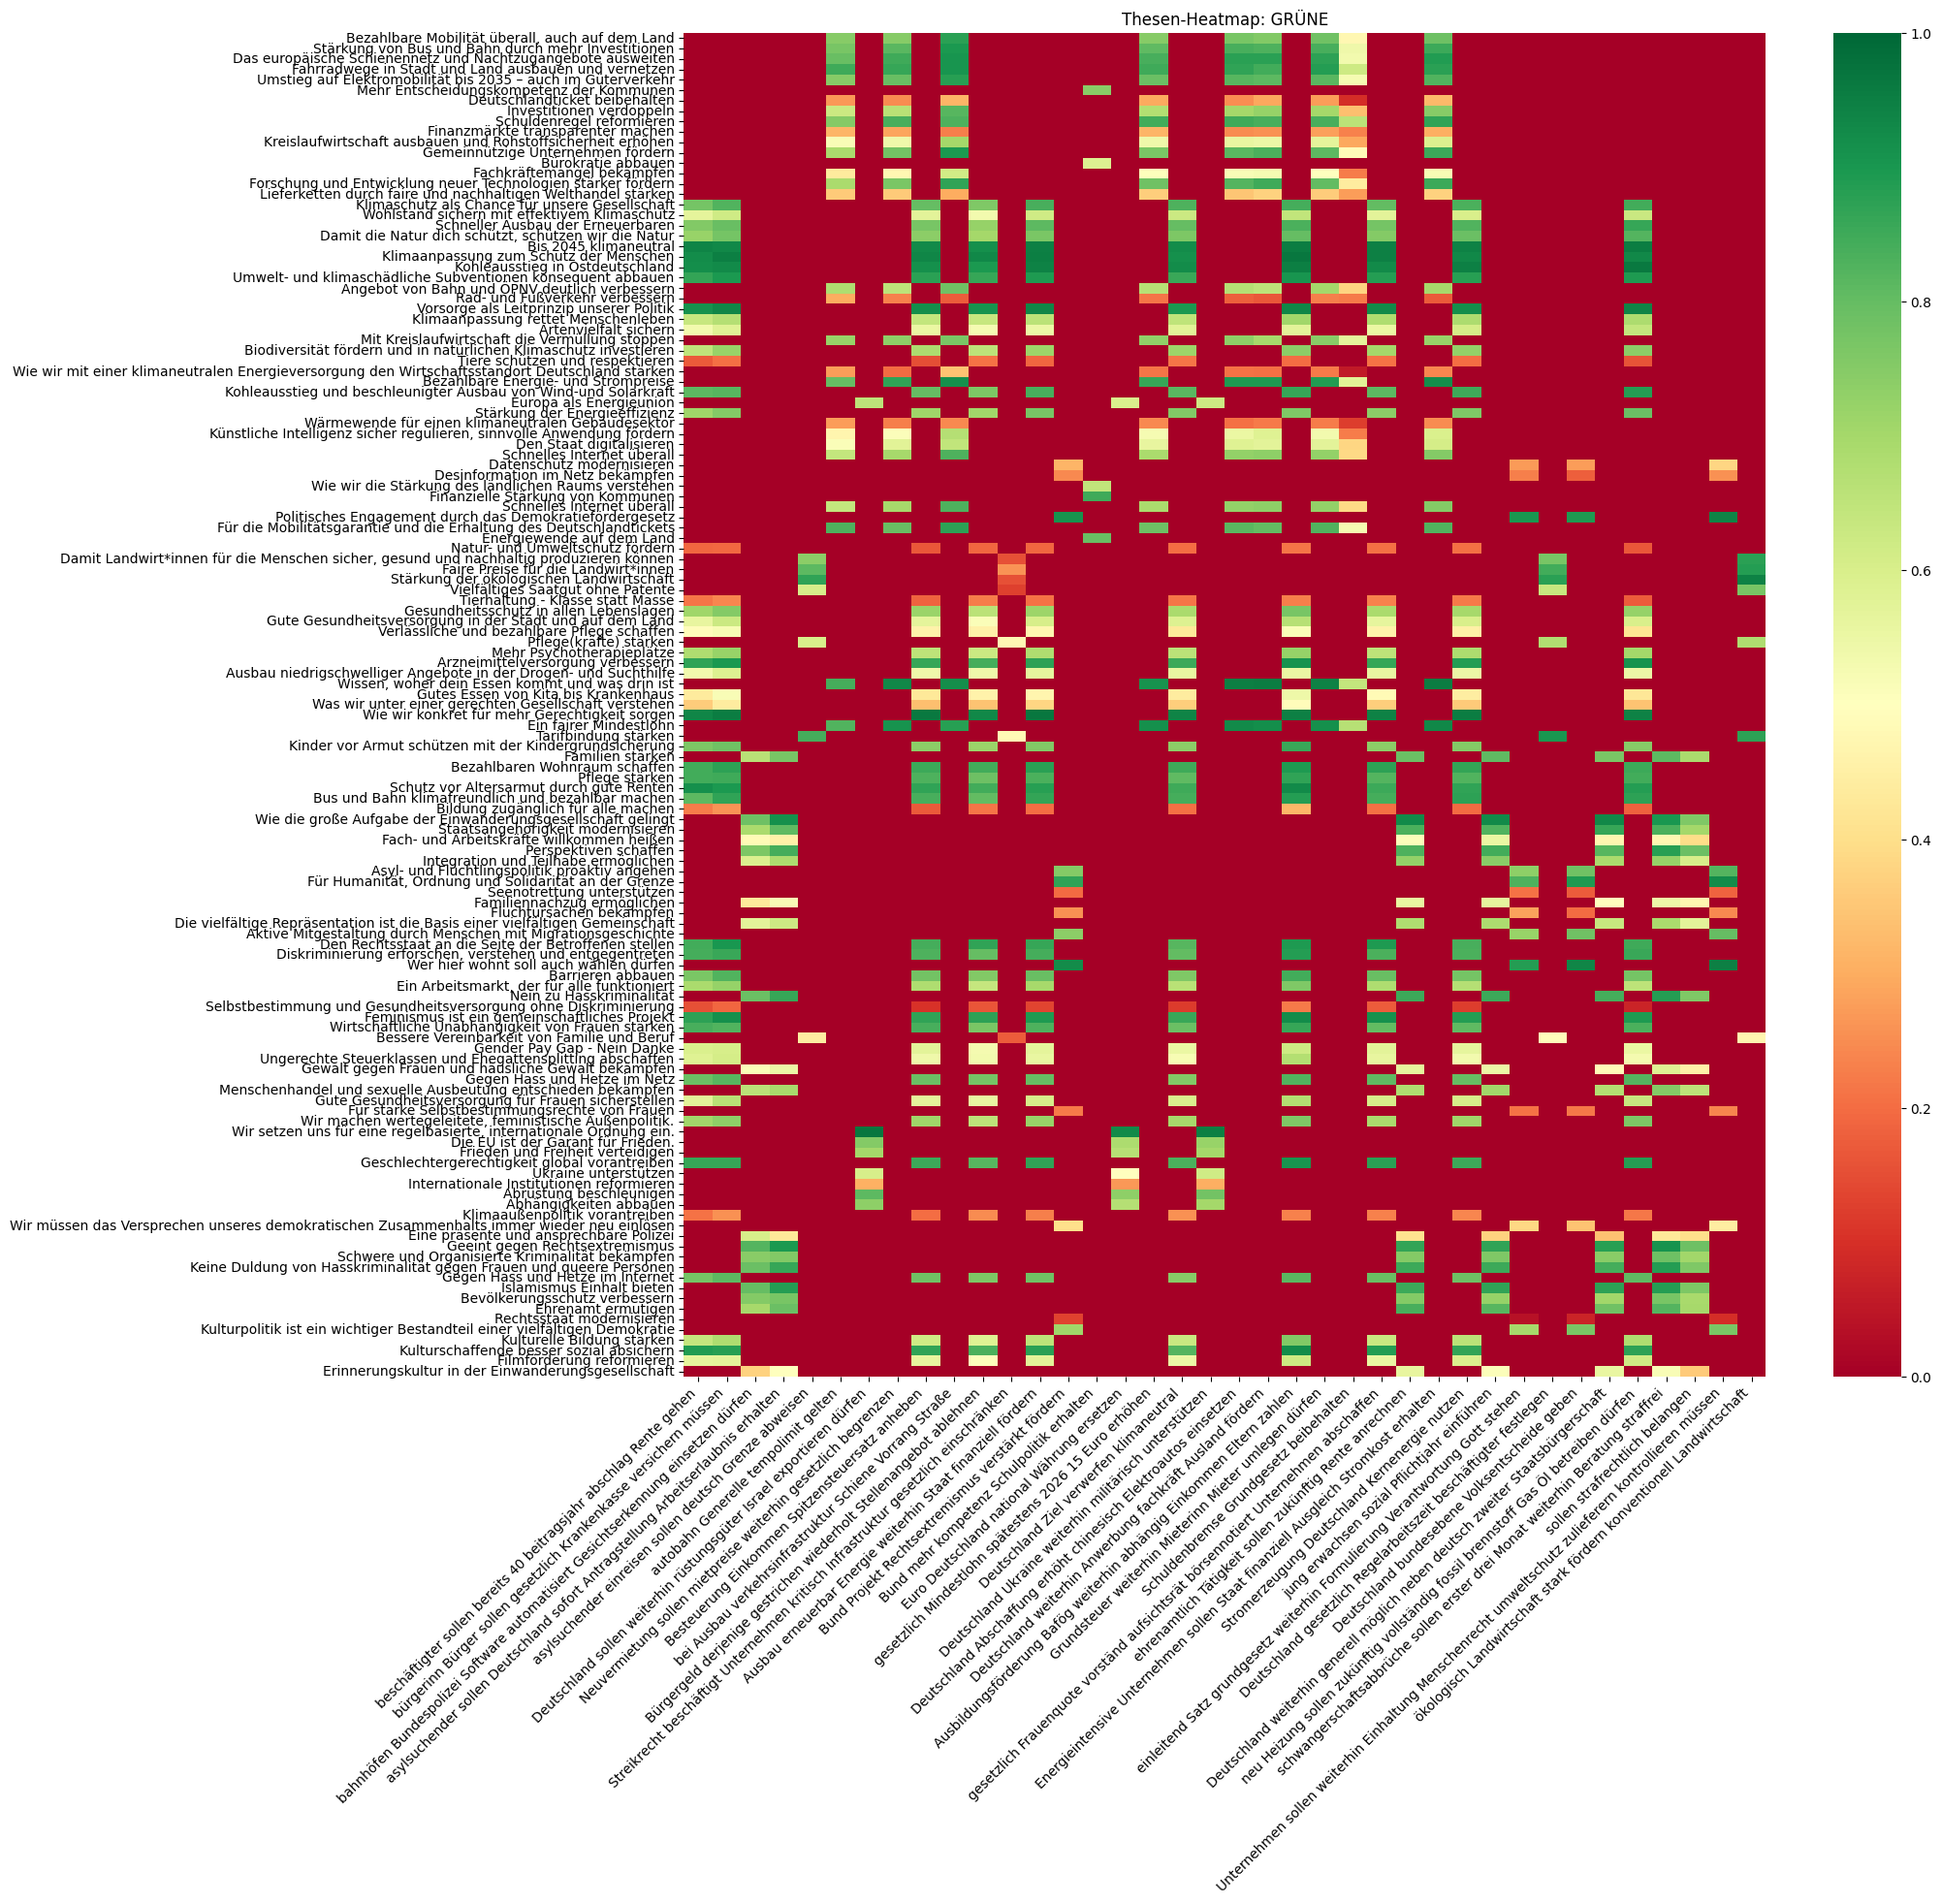

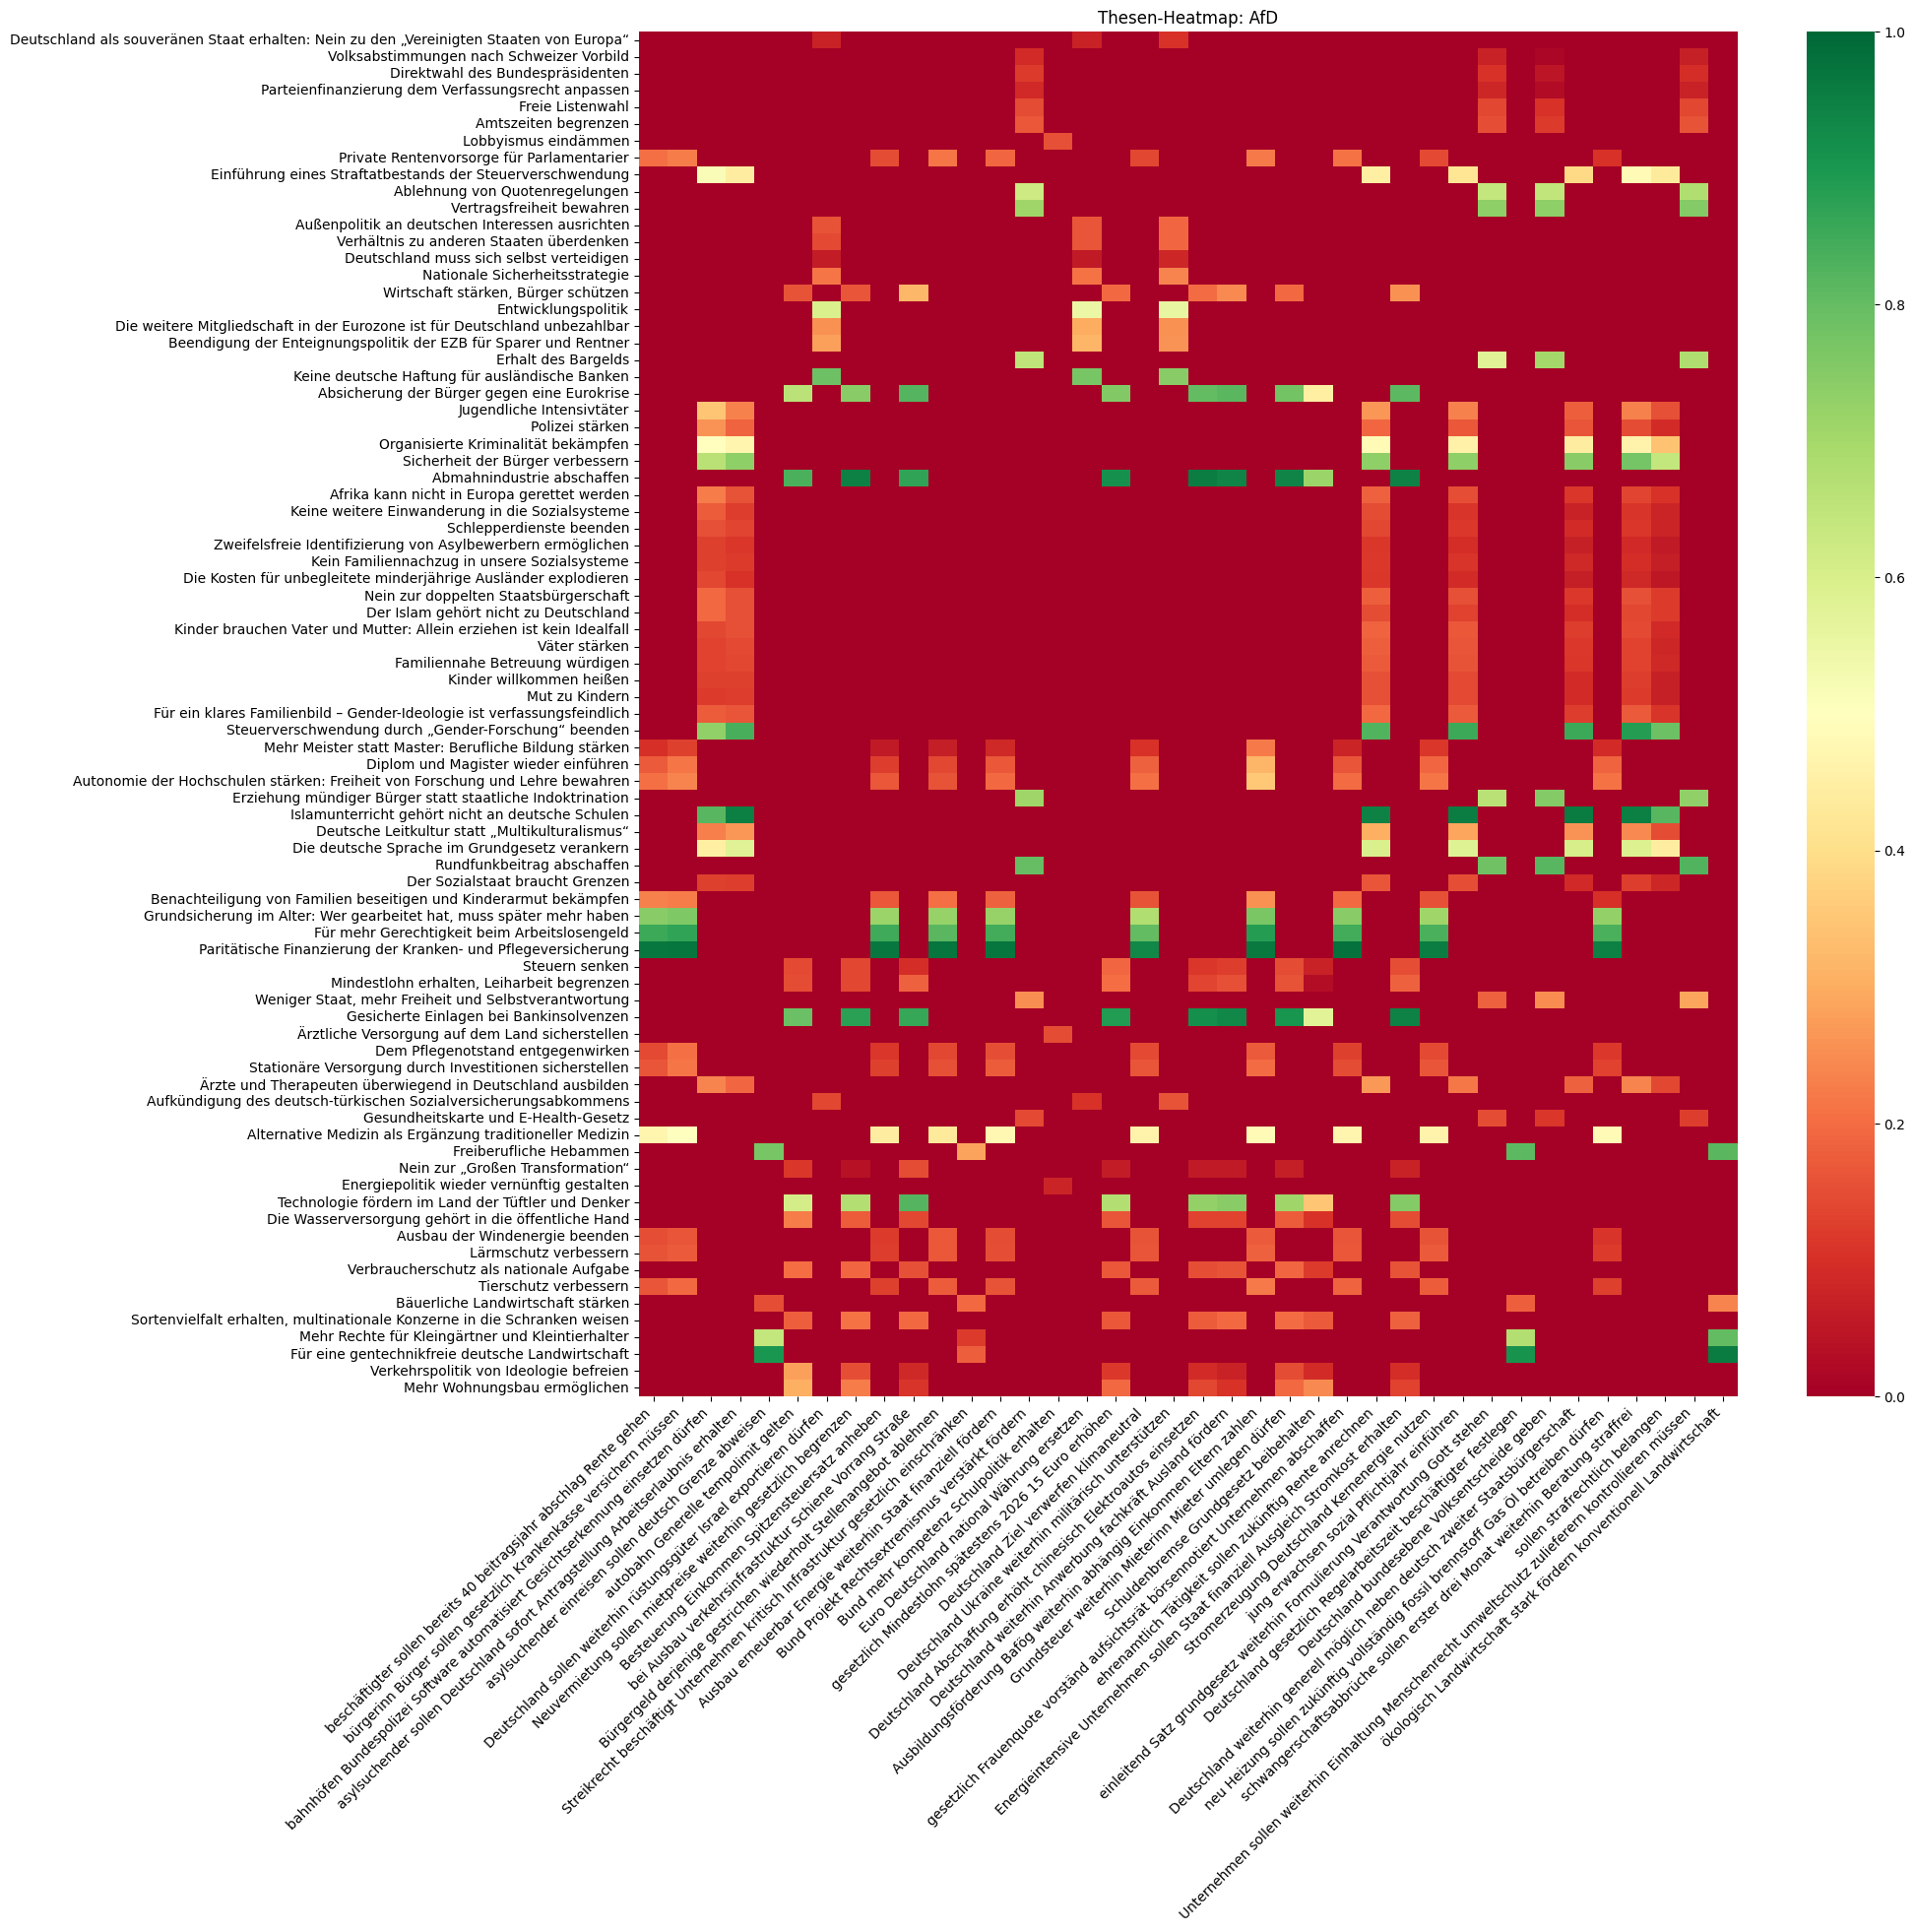

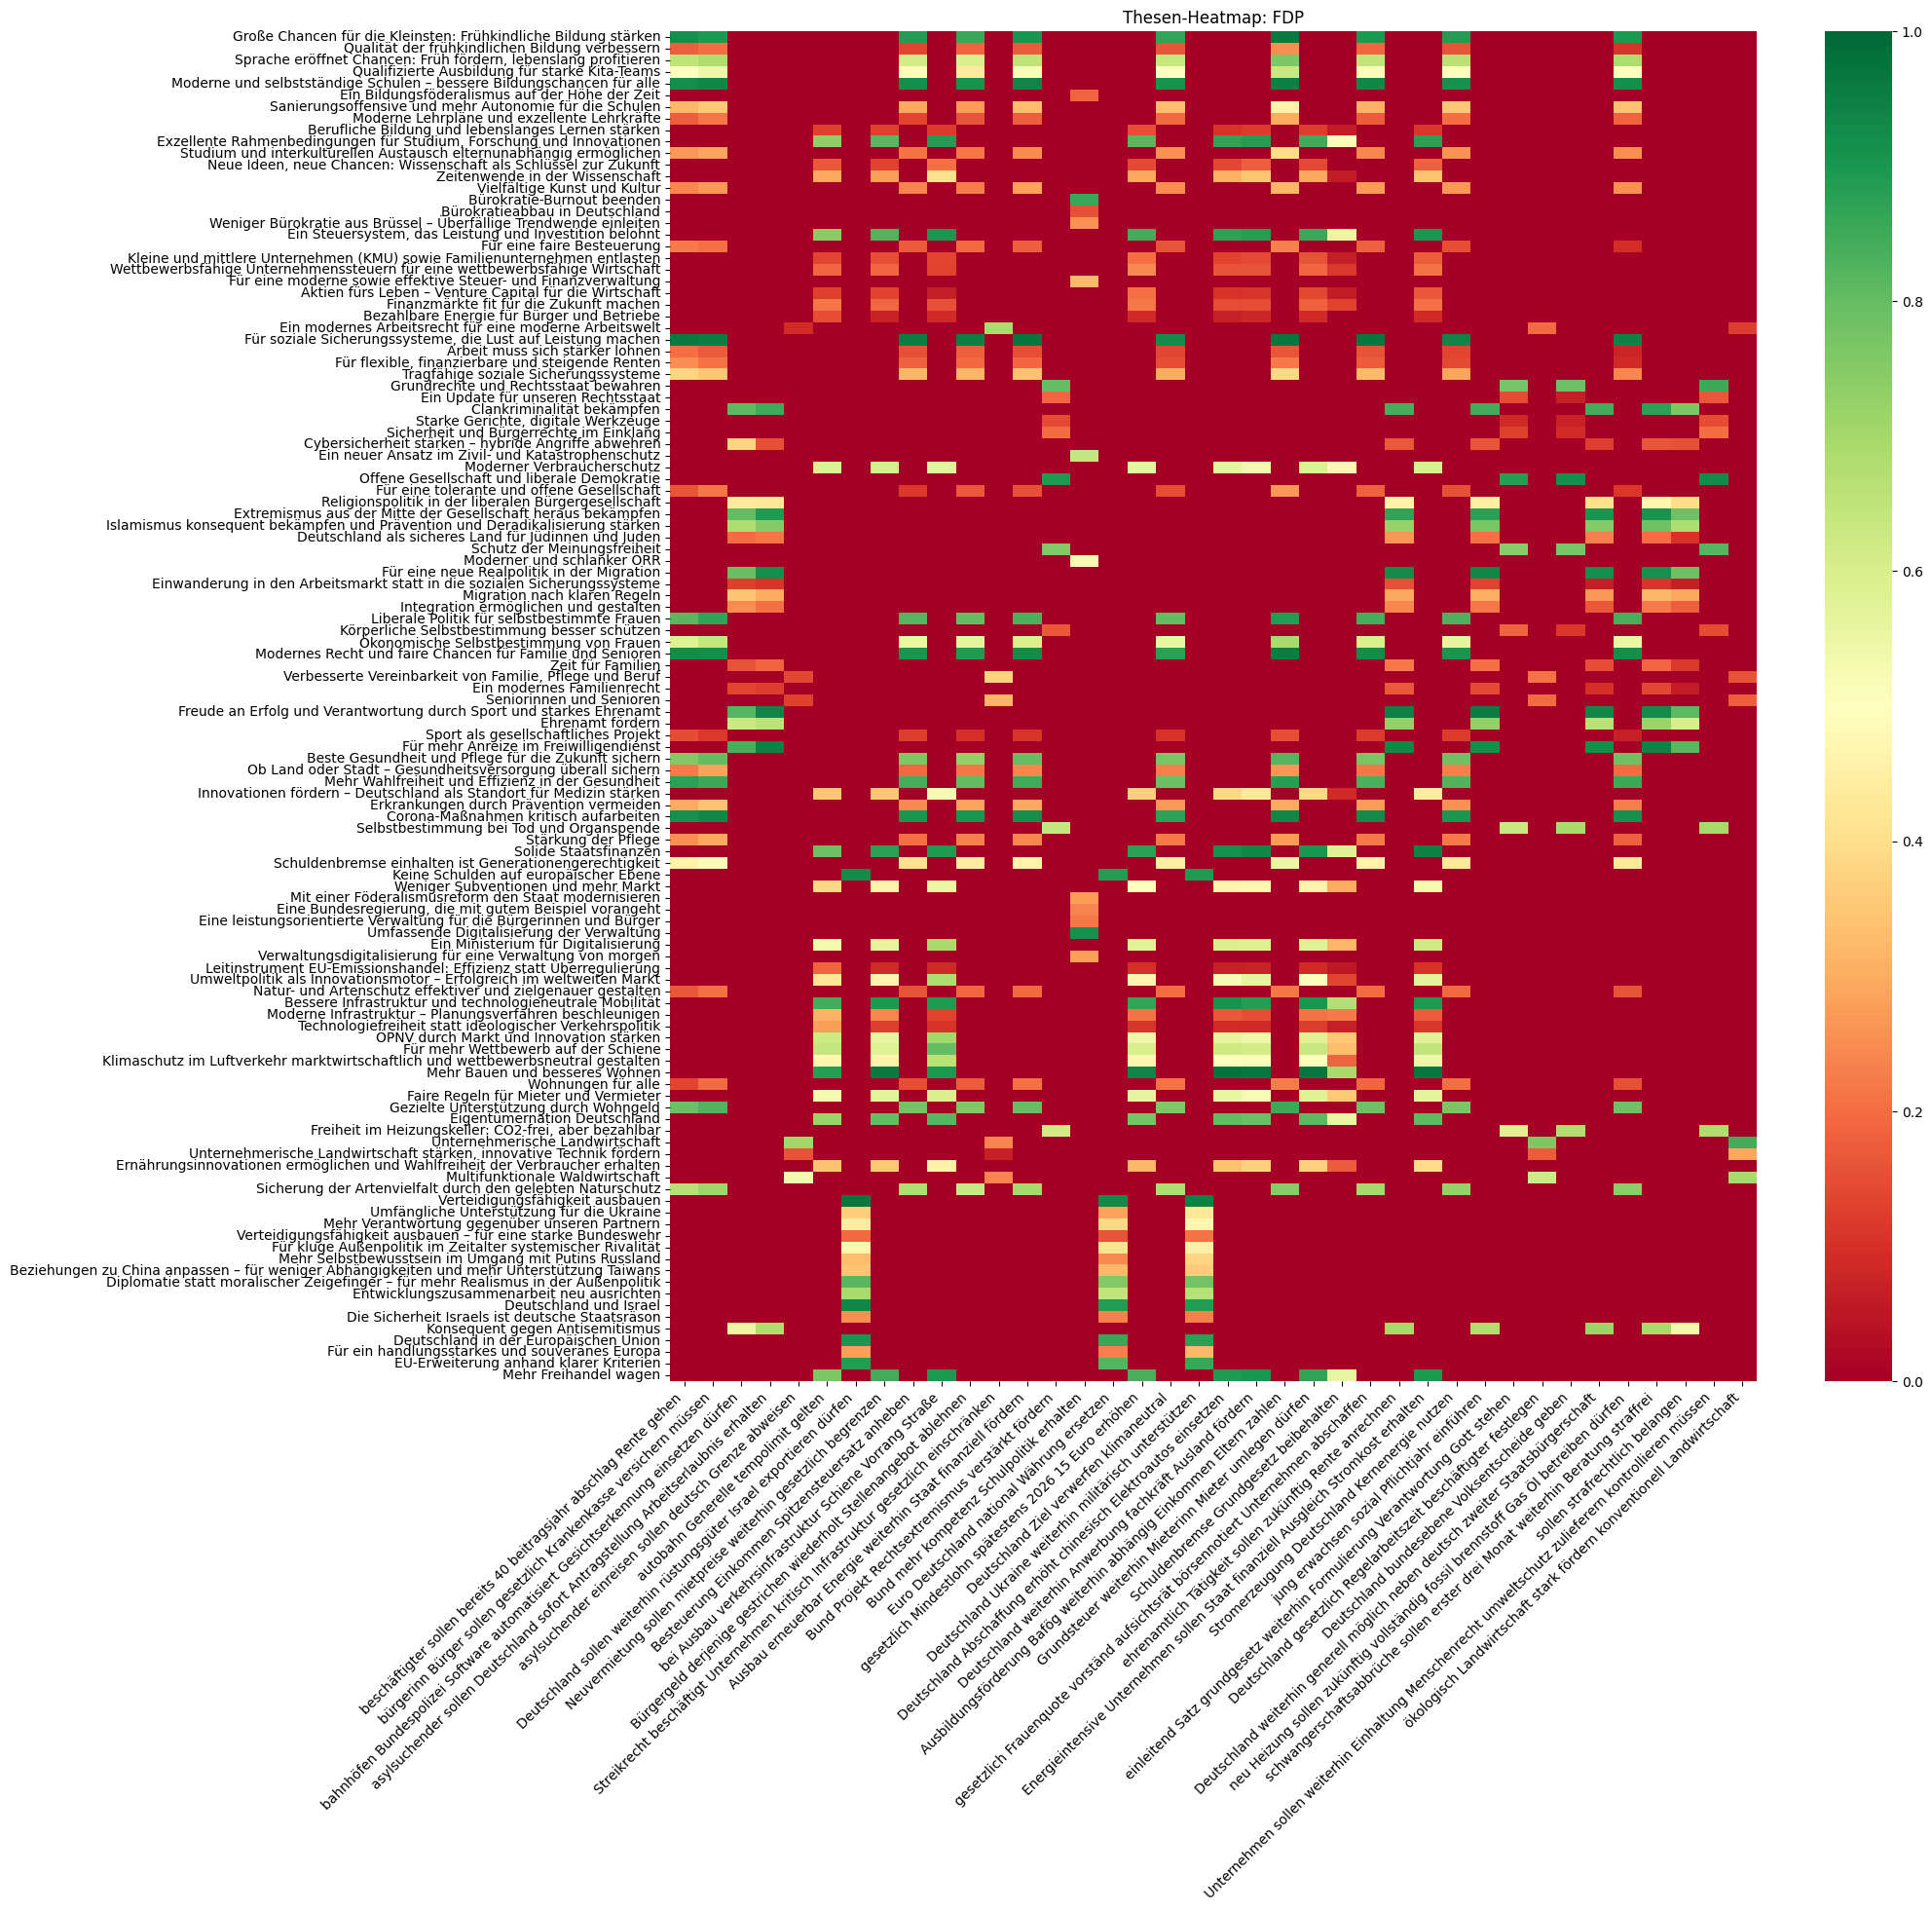

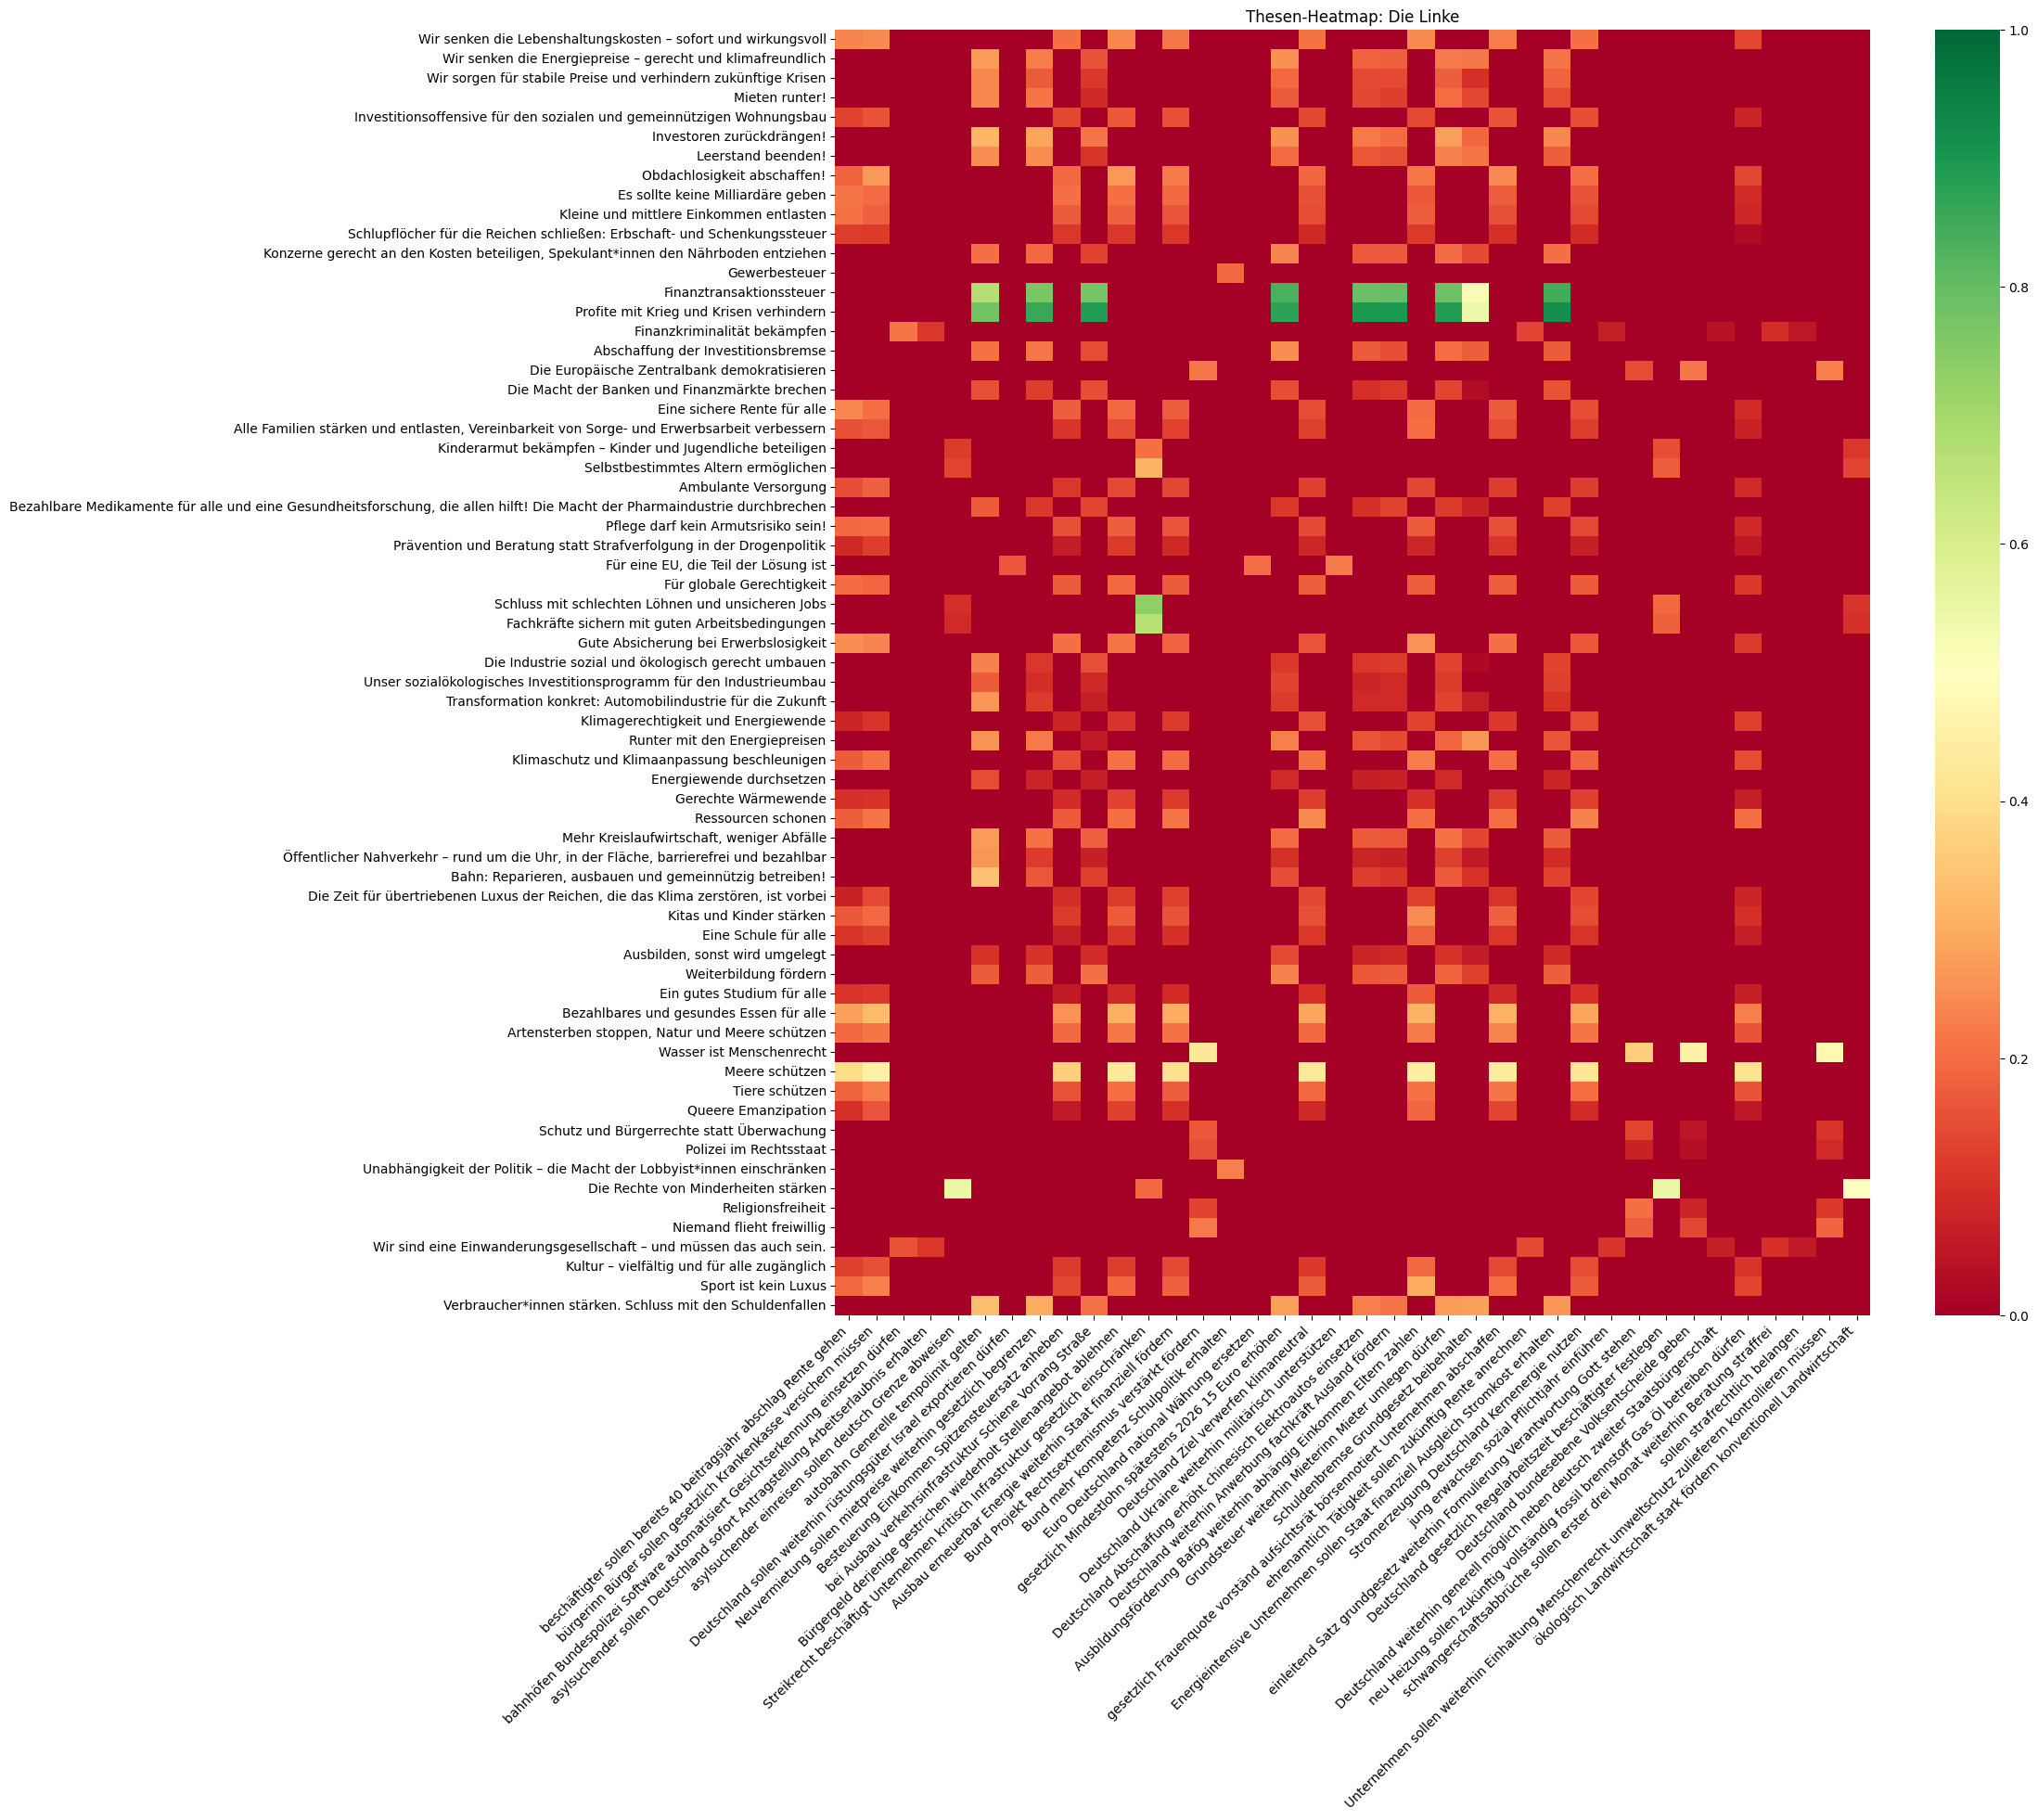

In [7]:
lable_text_column = 'These_lemmatized'
party_text_column = 'Text_lemmatized'
predicted_theses_dfs_dict, predicted_theses_df = similarity_func(all_party_textes_df,labled_theses_df,lable_text_column,party_text_column, plot=True, sort_by_classification=True)


Dieses NB:  
-> Funktion die die similarity ausgibt
-> Funktion die lables verteilt (Möglichkeit 1 und 2)  
-> Funktion die predicted Lable mit den true lable (confusion, acuraccy...)  
-> für alle modelle und Text-Kombinationen laufen lassen  

In [ ]:
party_name = 'AfD'
df = predicted_theses_dfs_dict[party_name]

party_best_simliarities_theses = pd.DataFrame(columns=['Party_These', 'Wahlomat_These', 'similarity', 'Wahlomat_lable'])
#Party_These	Best_Matching_Question	Jaccard_Score
for column in df.columns[1:]:
    max_similarity = df[column].max()
    max_index = df[column].idxmax()
    true_lable = labled_theses_df[labled_theses_df['These_lemmatized']== column][party_name].values[0]
    party_best_simliarities_theses.loc[len(party_best_simliarities_theses)] = [df.loc[max_index, 'party_text'], column, max_similarity, true_lable ]

party_best_simliarities_theses


In [139]:
lable_list = ["stimme nicht zu", "neutral", "stimme zu" ]

def mapping_similarity_to_class_func(predicted_theses_df:pd.DataFrame, lable_list:list):
    # Mapping-Funktion als Lambda-Ausdruck
    map_value = lambda val: (lable_list[0] if val <= 1/6 else
                             lable_list[1] if val <= 3/6 else
                             lable_list[2])
    
    # Kopie des DataFrames mit transformierten Werten
    predicted_theses_df_mapped = predicted_theses_df.copy()
    numeric_columns = predicted_theses_df.select_dtypes(include=['number']).columns
    predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
    
    # Anzeigen des gemappten DataFrames
    return predicted_theses_df_mapped

c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-d

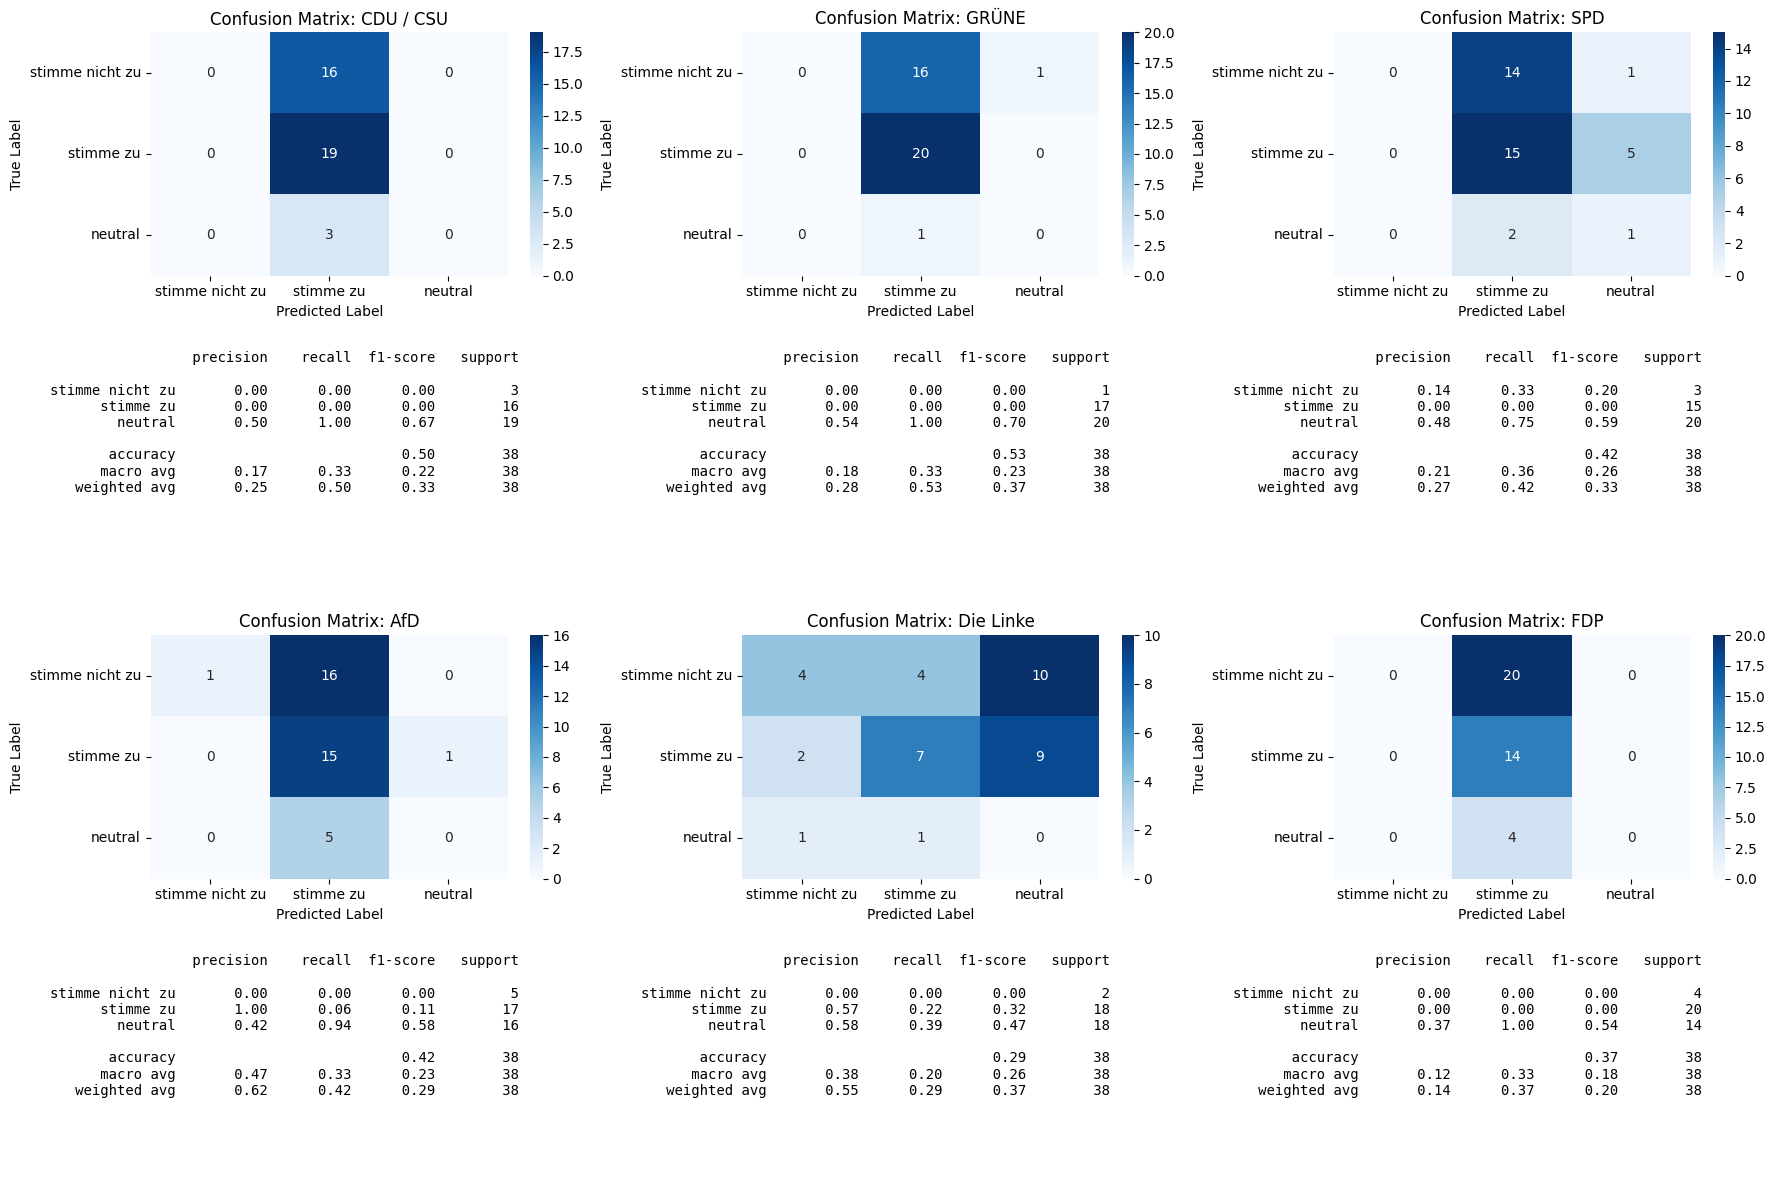

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import math

# Example parties_list
parties_list = ['CDU / CSU', 'GRÜNE', 'SPD', 'AfD', 'Die Linke', 'FDP']

# Get unique labels from the dataframe
labels = pd.unique(labled_theses_df[parties_list].values.ravel()).tolist()

cols_num = 3
rows_num = math.ceil(len(parties_list)/cols_num)
i, j = 0, 0

# Create subplots: We create more rows to accommodate both the heatmap and the classification report below
fig, ax = plt.subplots(ncols=cols_num, nrows=2*rows_num, figsize=(18, rows_num * 6))

# Loop through each party in the parties_list
for party in parties_list:
    # Compute confusion matrix
    cm = confusion_matrix(labled_theses_df[party], predicted_theses_df_mapped[party], labels=labels)
    
    # Generate classification report
    report_text = classification_report(labled_theses_df[party], predicted_theses_df_mapped[party], target_names=labels)

    # Plot confusion matrix (even rows for confusion matrices)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax[i,j])
    ax[i,j].set_xlabel("Predicted Label")
    ax[i,j].set_ylabel("True Label")
    ax[i,j].set_title(f"Confusion Matrix: {party}")

    # Display the classification report text below the confusion matrix (odd rows for reports)
    ax[i+1,j].axis('off')  # Hide the axis for the classification report
    ax[i+1,j].text(0.3, 0.6, report_text, fontsize=10, ha="center", va="center", family="monospace")

    i, j = (i, j + 1) if j < cols_num-1 else (i + 2, 0)

plt.tight_layout()  
plt.show()


In [142]:
labled_theses_df

,These,These_no_stopwords,These_lemmatized,These_unique_words,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP,Predicted_Class
0,Alle Beschäftigten sollen bereits nach 40 Beit...,beschäftigten sollen bereits 40 beitragsjahren...,beschäftigter sollen bereits 40 beitragsjahr a...,beschäftigter sollen bereits 40 beitragsjahr a...,stimme nicht zu,stimme nicht zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,504 - Welfare State Expansion
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,bürgerinnen bürger sollen gesetzlichen kranken...,bürgerinn Bürger sollen gesetzlich Krankenkass...,bürgerinn Bürger sollen gesetzlich Krankenkass...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu,504 - Welfare State Expansion
2,An Bahnhöfen soll die Bundespolizei Software z...,bahnhöfen bundespolizei software automatisiert...,bahnhöfen Bundespolizei Software automatisiert...,bahnhöfen Bundespolizei Software automatisiert...,stimme zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme nicht zu,605 - Law and Order: Positive
3,Asylsuchende sollen in Deutschland sofort nach...,asylsuchende sollen deutschland sofort antrags...,asylsuchender sollen Deutschland sofort Antrag...,asylsuchender sollen Deutschland sofort Antrag...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,neutral,602 - National Way of Life: Negative
4,"Asylsuchende, die über einen anderen EU-Staat ...",asylsuchende eingereist sollen deutschen grenz...,asylsuchender einreisen sollen deutsch Grenze ...,asylsuchender einreisen sollen deutsch Grenze ...,stimme zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme zu,705 - Underprivileged Minority Groups
5,Auf allen Autobahnen soll ein generelles Tempo...,autobahnen generelles tempolimit gelten,autobahn Generelle tempolimit gelten,autobahn Generelle tempolimit gelten,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu,411 - Technology and Infrastructure
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,deutschland sollen weiterhin rüstungsgüter isr...,Deutschland sollen weiterhin rüstungsgüter Isr...,Deutschland sollen weiterhin rüstungsgüter Isr...,stimme zu,stimme zu,stimme zu,neutral,stimme nicht zu,stimme zu,107 - Internationalism: Positive
7,Bei Neuvermietungen sollen die Mietpreise weit...,neuvermietungen sollen mietpreise weiterhin ge...,Neuvermietung sollen mietpreise weiterhin gese...,Neuvermietung sollen mietpreise weiterhin gese...,stimme zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu,412 - Controlled Economy
8,Bei der Besteuerung von Einkommen soll der Spi...,besteuerung einkommen spitzensteuersatz angehoben,Besteuerung Einkommen Spitzensteuersatz anheben,Besteuerung Einkommen Spitzensteuersatz anheben,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu,503 - Equality: Positive
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,beim ausbau verkehrsinfrastruktur schiene vorr...,bei Ausbau verkehrsinfrastruktur Schiene Vorra...,bei Ausbau verkehrsinfrastruktur Schiene Vorra...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu,411 - Technology and Infrastructure


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

parties_list = ['CDU / CSU', 'GRÜNE', 'SPD', 'AfD', 'Die Linke', 'FDP']

def prediction_metric_func(predicted_theses_df_mapped:pd.DataFrame,
                           labled_theses_df:pd.DataFrame,
                           parties_list:list,
                           plot:bool=False,
                           plot_title:str=''):
    

    # Get unique labels from the dataframe
    labels = pd.unique(labled_theses_df[parties_list].values.ravel()).tolist()

    target_lables_array = labled_theses_df[parties_list].values.ravel()
    predicted_lables_array = predicted_theses_df_mapped[parties_list].values.ravel()

    accuracy    = accuracy_score(target_lables_array, predicted_lables_array)
    precision   = precision_score(target_lables_array, predicted_lables_array, average="macro")
    recall      = recall_score(target_lables_array, predicted_lables_array, average="macro")
    f1          = f1_score(target_lables_array, predicted_lables_array, average="macro")

    if plot:
        # Confusion Matrix berechnen
        cm = confusion_matrix(target_lables_array,
                            predicted_lables_array,
                            labels=labels)

        # Classification Report als einfachen String holen
        report_text = classification_report(target_lables_array,
                                            predicted_lables_array,
                                            labels=labels,
                                            target_names=labels)

        # Plot erstellen
        fig, ax = plt.subplots(figsize=(6, 6))

        # Heatmap zeichnen
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
        ax.set_xlabel("Predicted Label")
        ax.set_ylabel("True Label")
        ax.set_title(plot_title)

        # Classification Report als Text im Plot ausgeben
        plt.gcf().text(0.07, 0.15, report_text, fontsize = 10, ha="left", va="center", family="monospace")

        plt.subplots_adjust(bottom=0.4)  # Falls der Text unten abgeschnitten wird

        plt.show()

    return [accuracy, precision, recall, f1]


all_party_textes_df.columns:  
'These', 'These_no_stopwords', 'These_lemmatized', 'These_unique_words',  
'Text',  'Text_no_stopwords',  'Text_lemmatized',  


labled_theses_df.columns:  
'These', 'These_no_stopwords', 'These_lemmatized', 'These_unique_words'  

In [132]:
labled_theses_df.columns

Index(['These', 'These_no_stopwords', 'These_lemmatized', 'These_unique_words',
       'CDU / CSU', 'GRÜNE', 'SPD', 'AfD', 'Die Linke', 'FDP',
       'Predicted_Class'],
      dtype='object')

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)


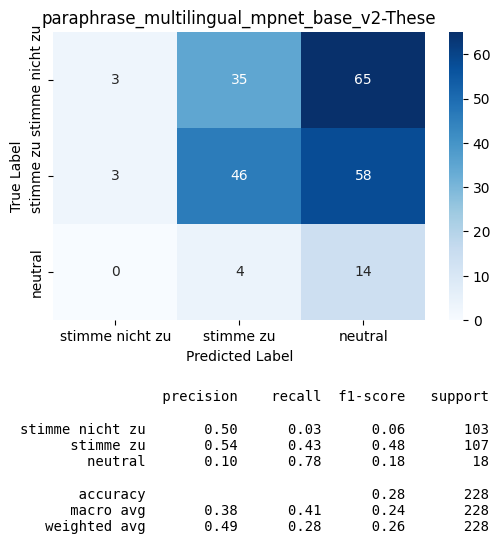

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)


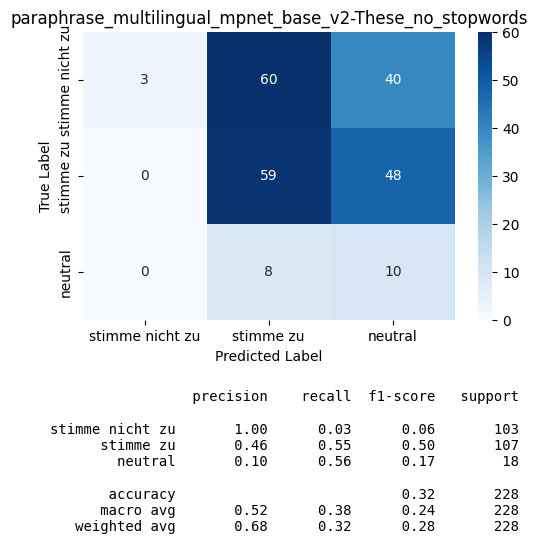

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)


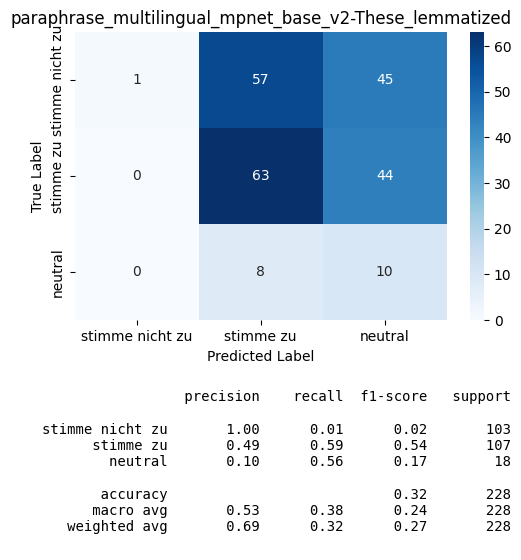

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)


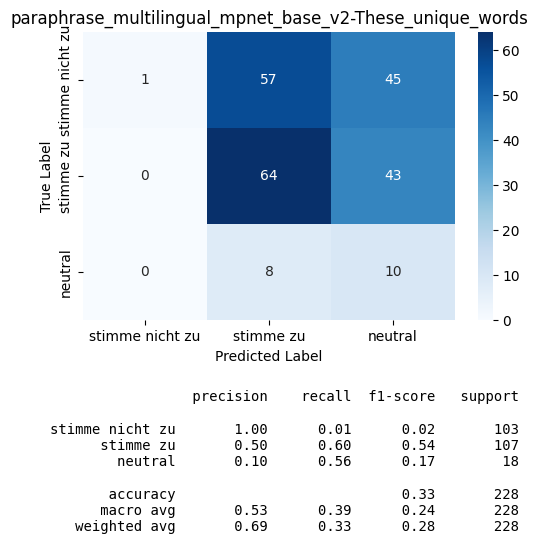

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

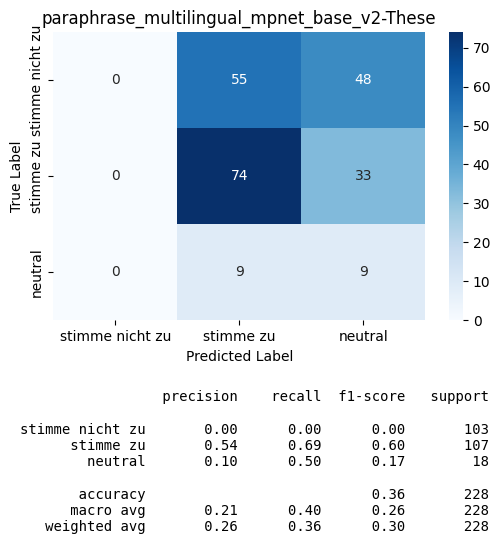

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

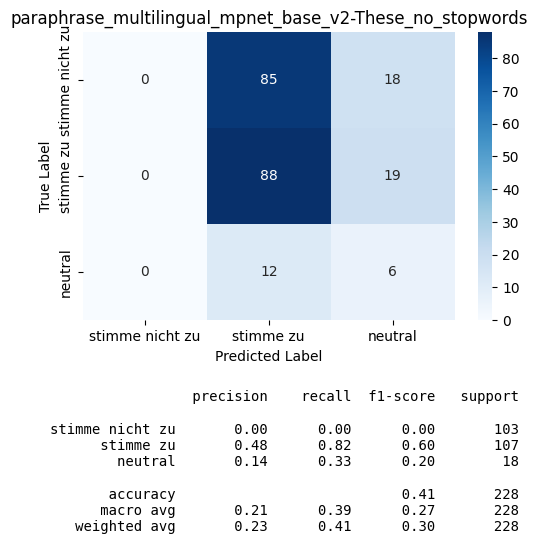

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

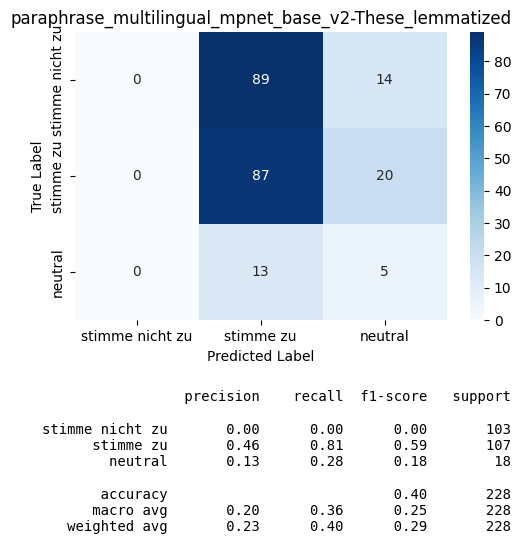

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

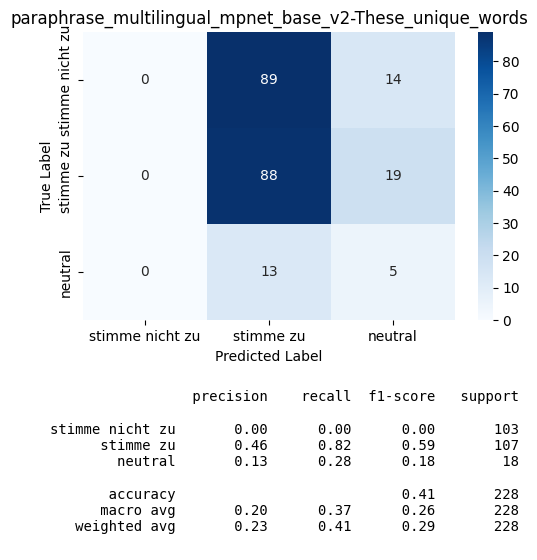

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

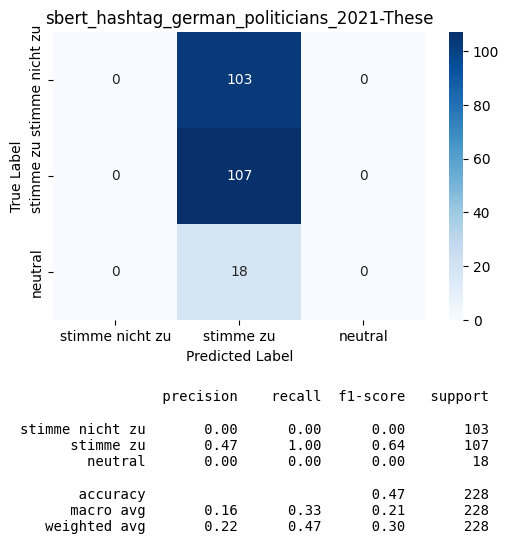

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

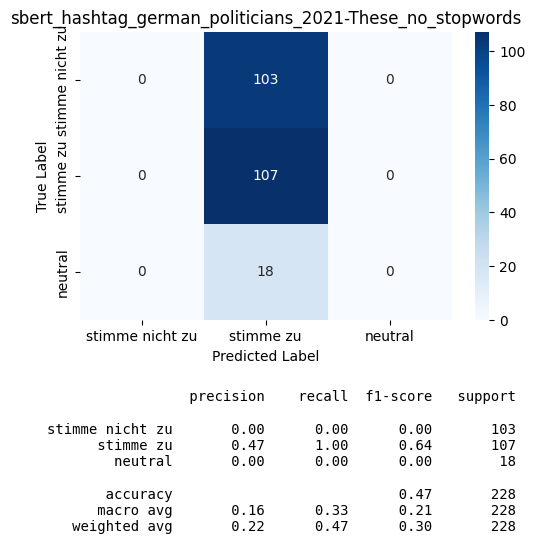

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

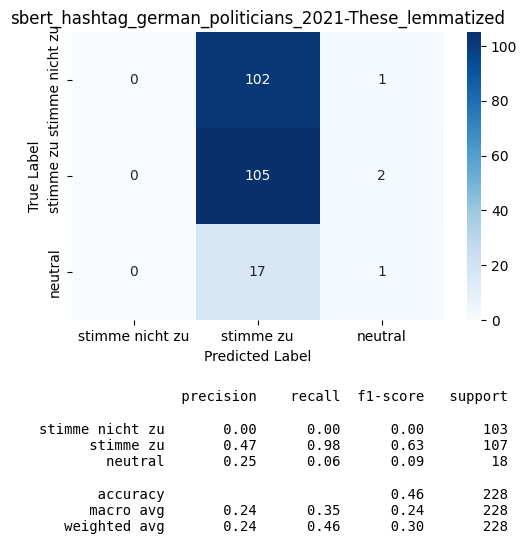

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

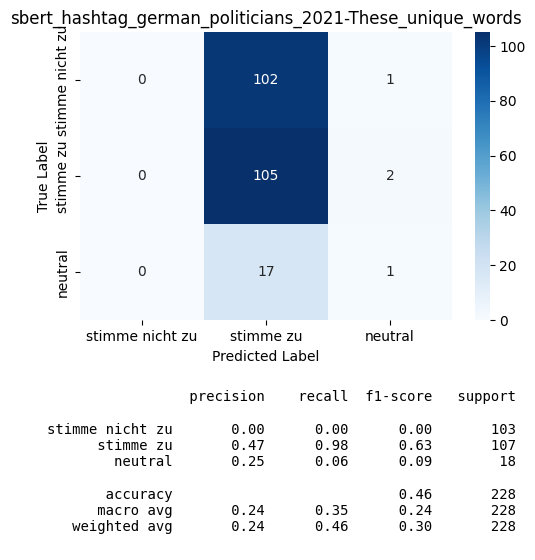

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

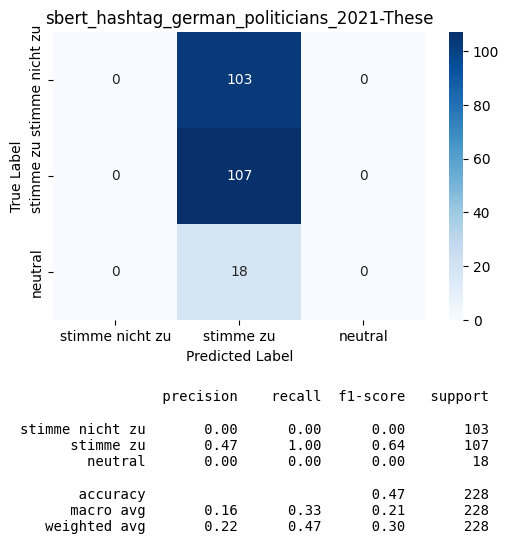

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

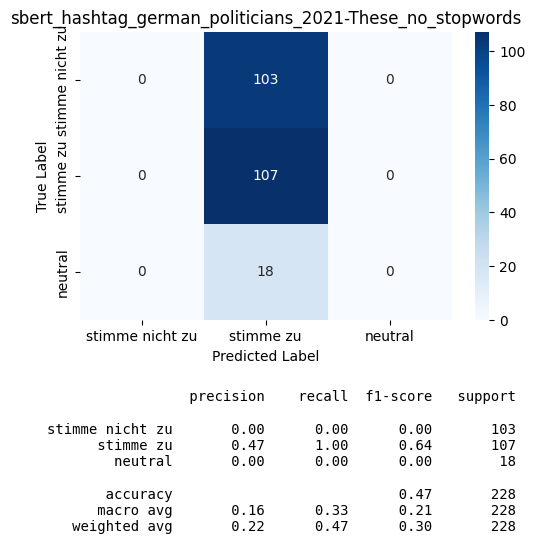

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

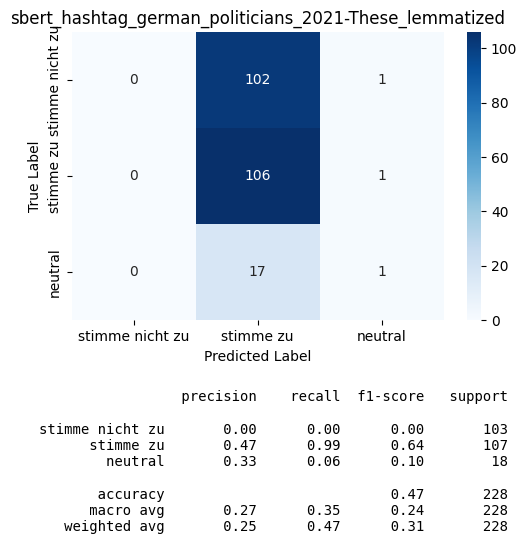

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

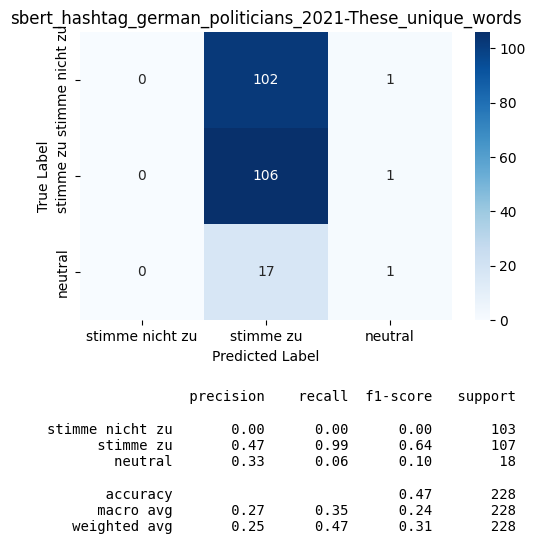

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)


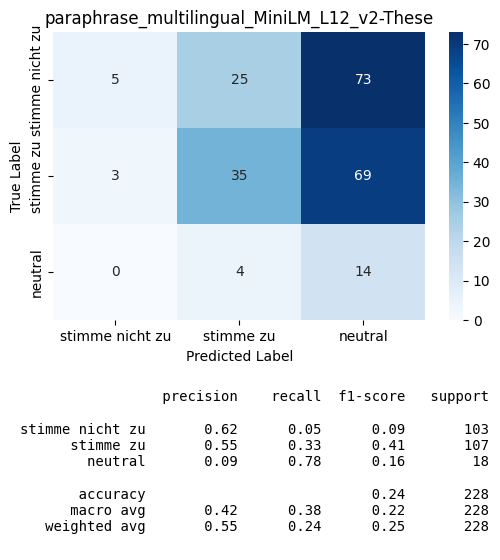

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)


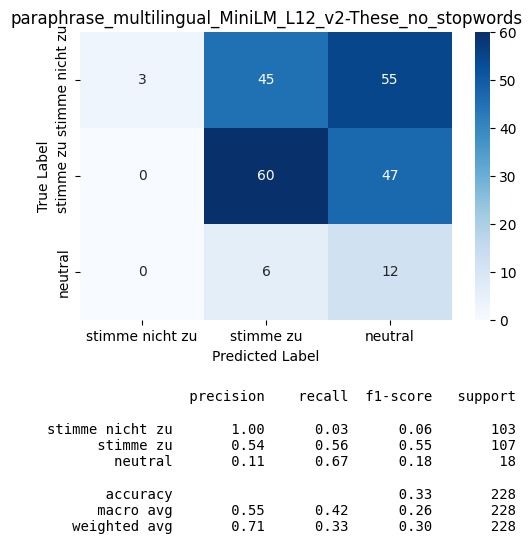

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)


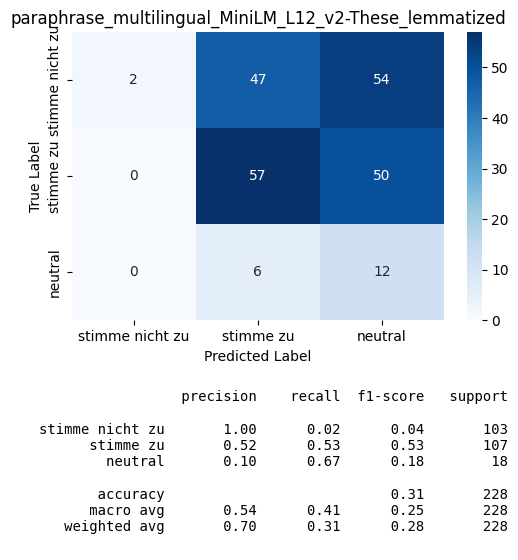

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)


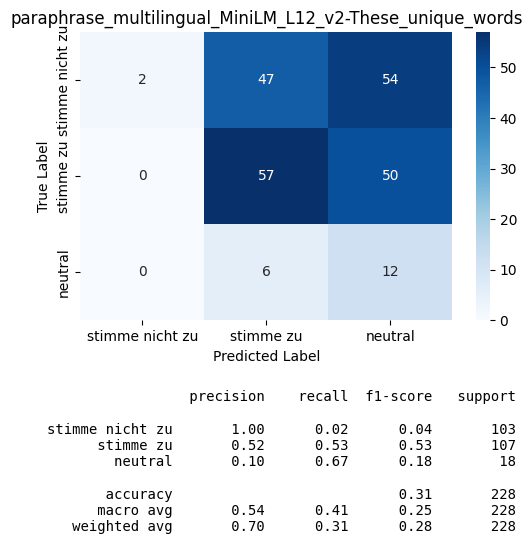

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

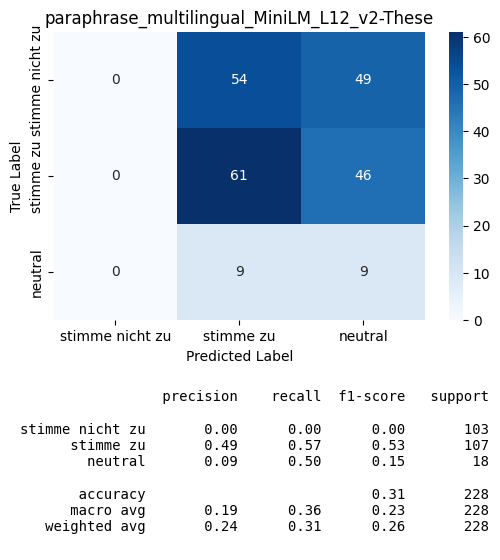

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

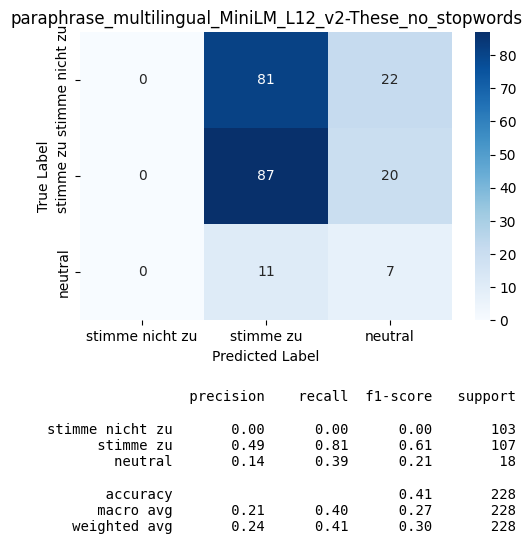

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

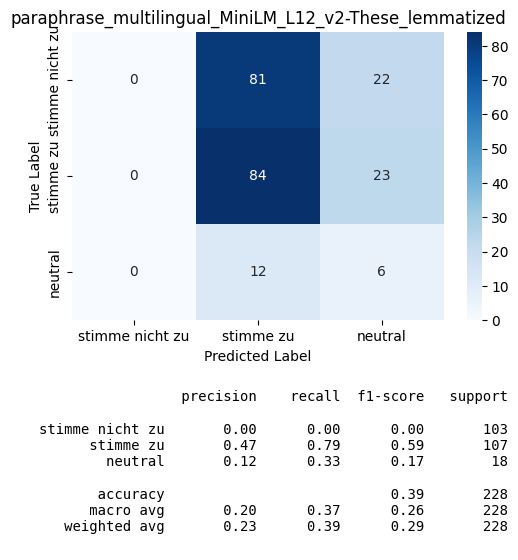

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

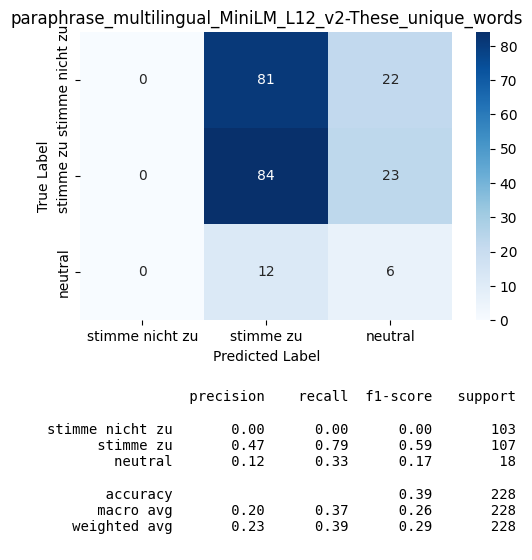

In [140]:
import os
import pickle

models_list = ['sentence-transformers/paraphrase-multilingual-mpnet-base-v2', 'mmmaurer/sbert-hashtag-german-politicians-2021', "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"]
model_names_list = ['paraphrase_multilingual_mpnet_base_v2', 'sbert_hashtag_german_politicians_2021', 'paraphrase_multilingual_MiniLM_L12_v2']
text_columns_list = ['These', 'These_no_stopwords', 'These_lemmatized', 'These_unique_words']

lable_list = ["stimme nicht zu", "neutral", "stimme zu"]
parties_list = ['CDU / CSU', 'GRÜNE', 'SPD', 'AfD', 'Die Linke', 'FDP']

folder_path = r'Prediction_Data\Theses'

# Socres:   [accuracy, precision, recall, f1]
Model_prediction_scores = pd.DataFrame(columns= ['model', 'lable_text_column', 'party_text_column' ,'Manifesto_sorted', 'accuracy', 'precision', 'recall', 'f1'])


for idx, model in enumerate(models_list):
    tokenizer = AutoTokenizer.from_pretrained(model)
    model = AutoModel.from_pretrained(model)

    
    #
    for sort_by_state in [True, False]:
        for text_column in text_columns_list:

            lable_text_column = text_column
            party_text_column = text_column
            predicted_theses_dfs_dict, predicted_theses_df = similarity_func(all_party_textes_df,
                                                                             labled_theses_df,
                                                                             lable_text_column,
                                                                             party_text_column, 
                                                                             plot=False, 
                                                                             sort_by_classification=sort_by_state)

            folder_path_file = os.path.join(folder_path,model_names_list[idx], f'Manifesto_sorted_{sort_by_state}', text_column)
            os.makedirs(folder_path_file, exist_ok=True)

            with open(os.path.join(folder_path_file, 'predicted_theses_dfs_dict.pkl'), 'wb') as f:
                pickle.dump(predicted_theses_dfs_dict, f)

            with open(os.path.join(folder_path_file, 'predicted_theses_df.pkl'), 'wb') as f:
                pickle.dump(predicted_theses_df, f)

            #TODO Mapping des predicted theses dfs
            predicted_theses_df_mapped = mapping_similarity_to_class_func(predicted_theses_df, lable_list)

            #TODO Apply Metric to evaluate Predictions
            scores_list = prediction_metric_func(predicted_theses_df_mapped, labled_theses_df, parties_list, plot=True, plot_title=f'{model_names_list[idx]}-{text_column}')
            #TODO Save Metrics in df to compare
            Model_prediction_scores.loc[len(Model_prediction_scores)] = [model_names_list[idx], lable_text_column, party_text_column, sort_by_state ]+scores_list
            
with open(os.path.join(folder_path, 'Model_prediction_scores.pkl'), 'wb') as f:
    pickle.dump(Model_prediction_scores, f)

all_party_textes_df.columns:  
'These', 'These_no_stopwords', 'These_lemmatized', 'These_unique_words',  
'Text',  'Text_no_stopwords',  'Text_lemmatized',  


labled_theses_df.columns:  
'These', 'These_no_stopwords', 'These_lemmatized', 'These_unique_words'  

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

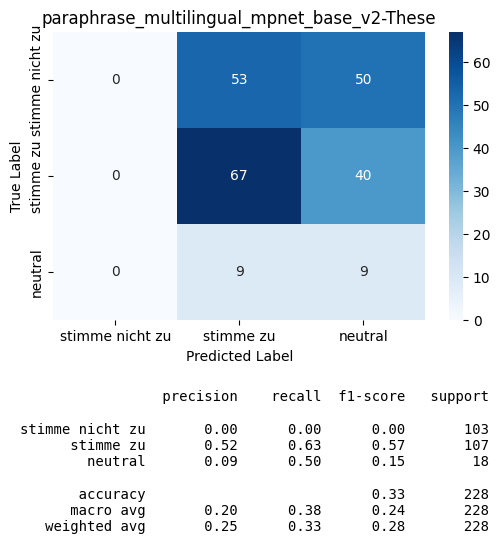

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

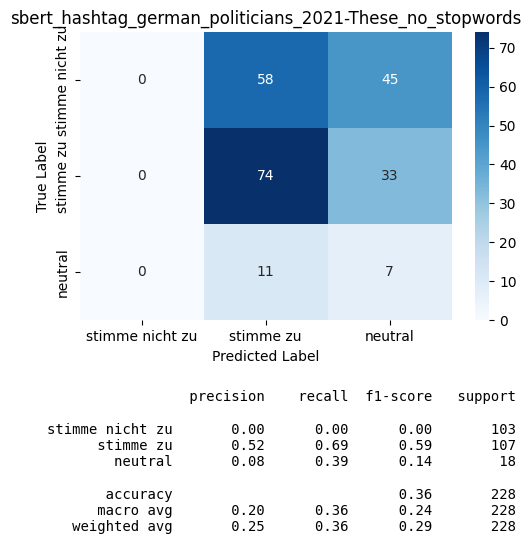

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

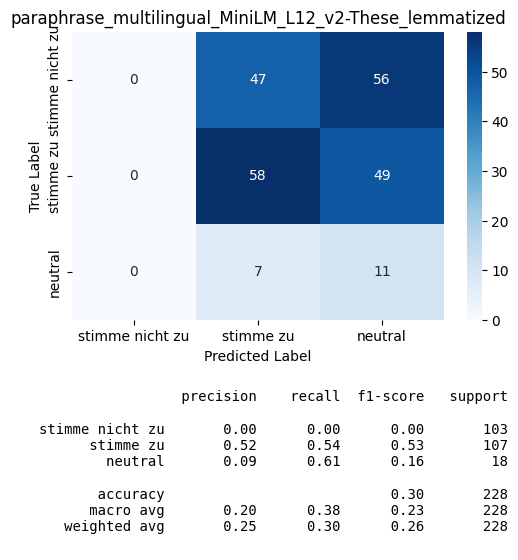

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

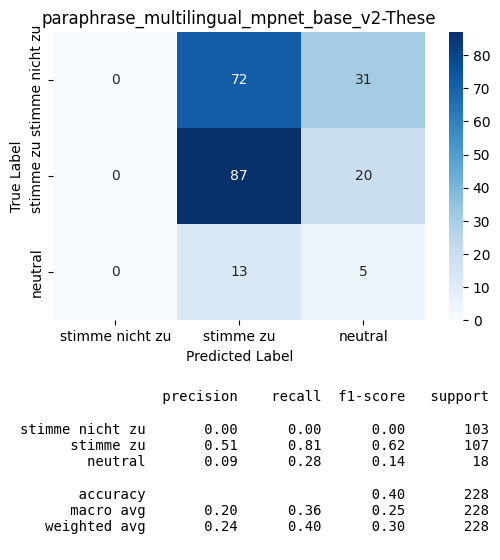

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

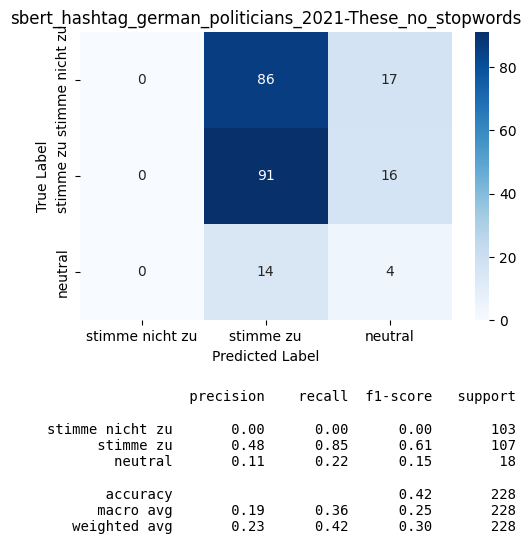

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

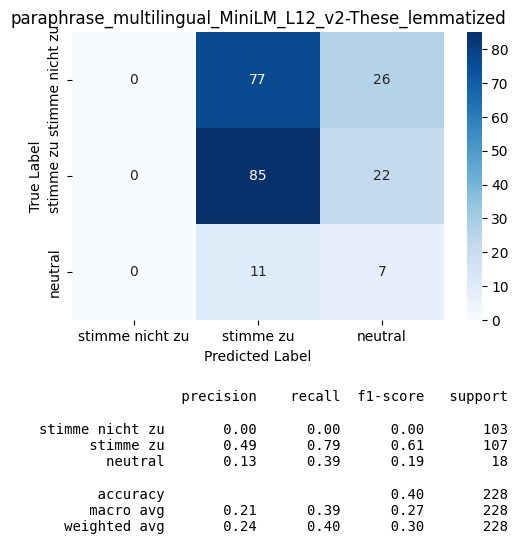

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)


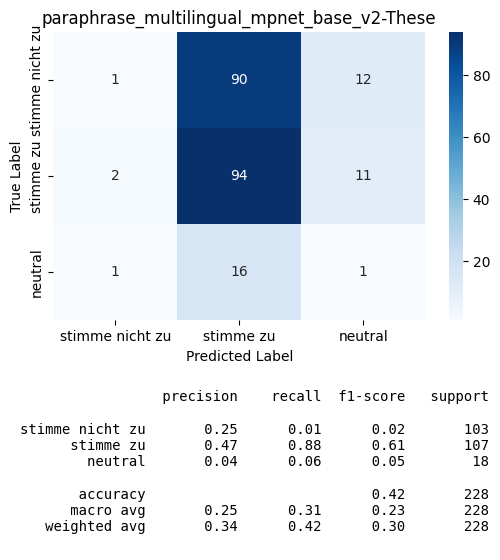

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)


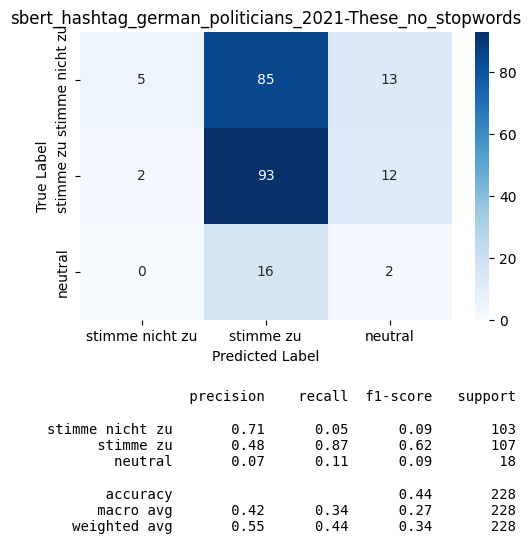

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)


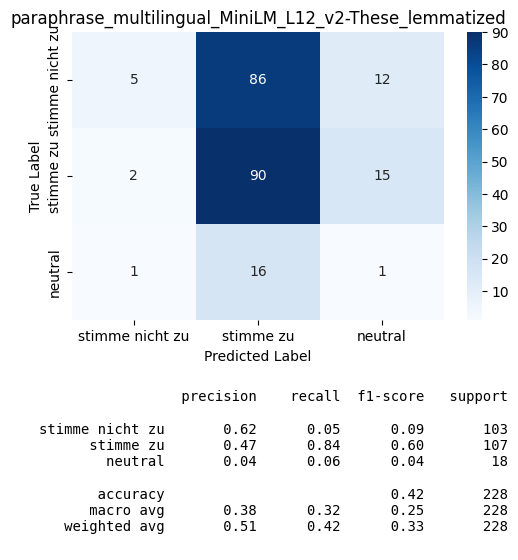

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

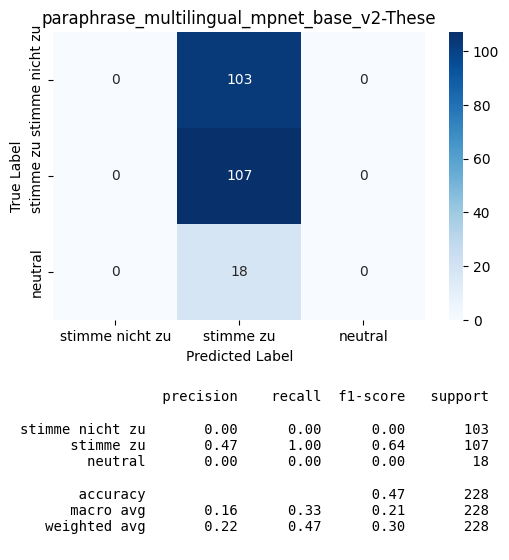

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

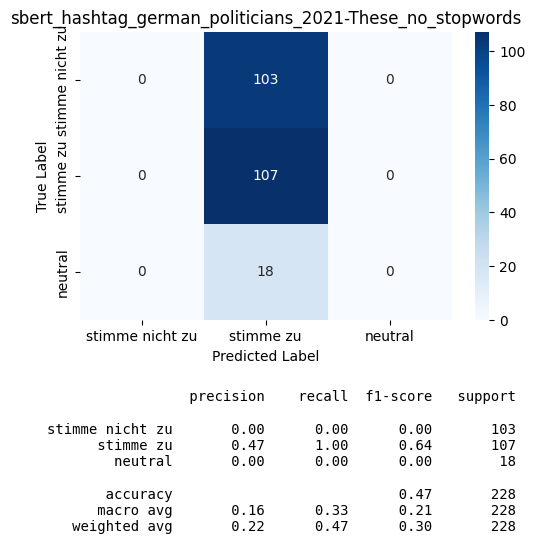

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

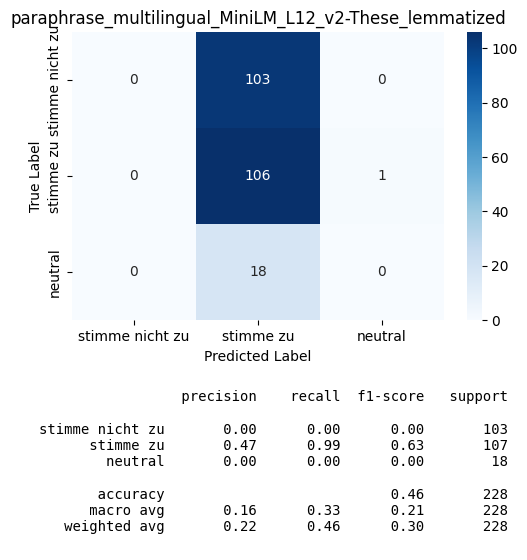

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)


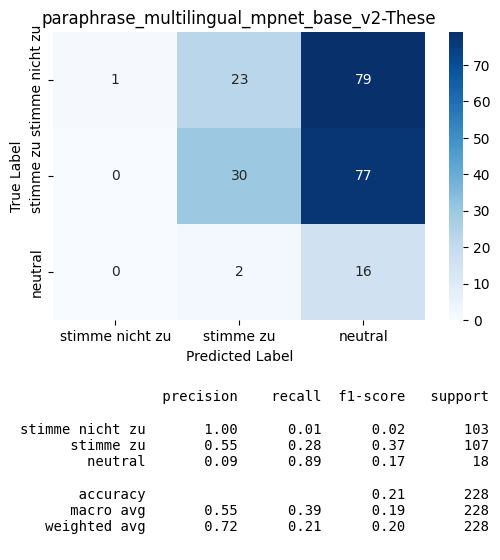

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)


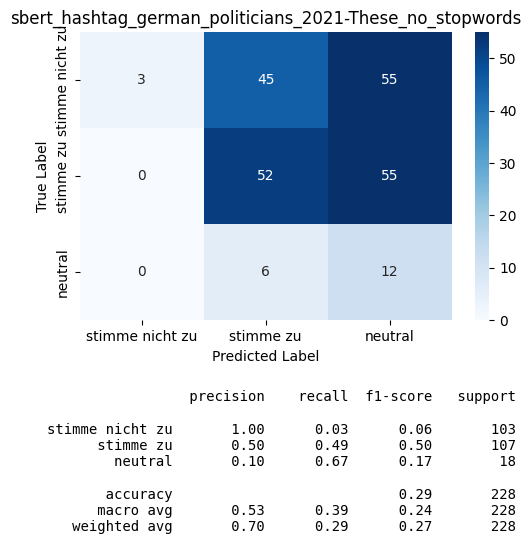

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)


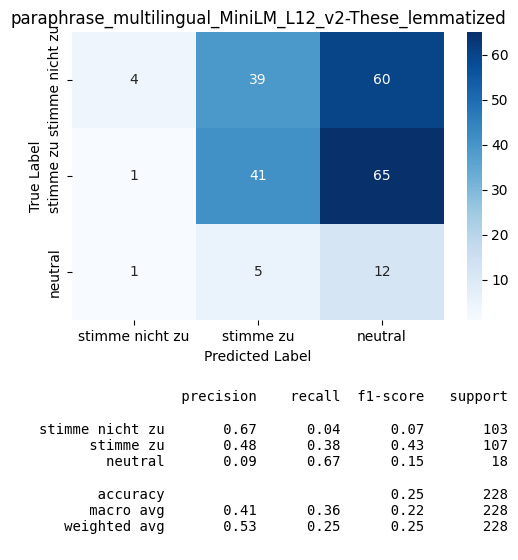

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

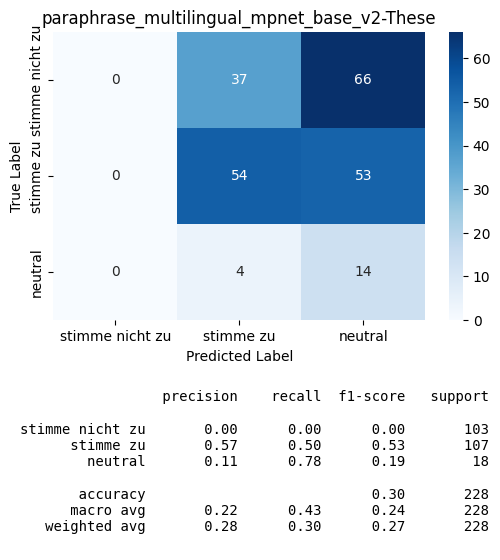

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

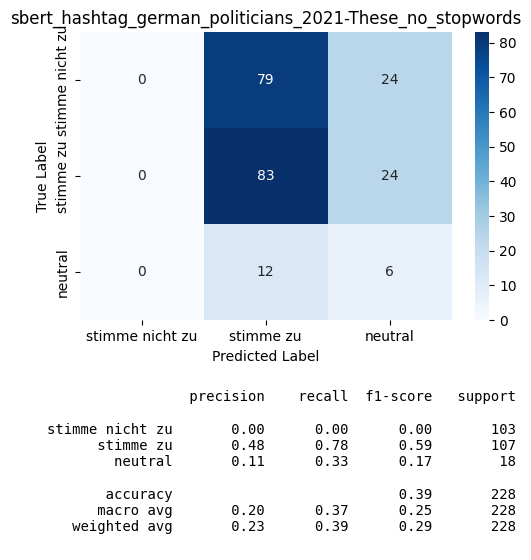

C:\Users\lnieb\AppData\Local\Temp\ipykernel_9176\869251079.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predicted_theses_df_mapped[numeric_columns] = predicted_theses_df_mapped[numeric_columns].applymap(map_value)
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lnieb\Desktop\Studium\03_Organisation\24T4\Text Mining und Web Analysis\LGit_TextMining\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

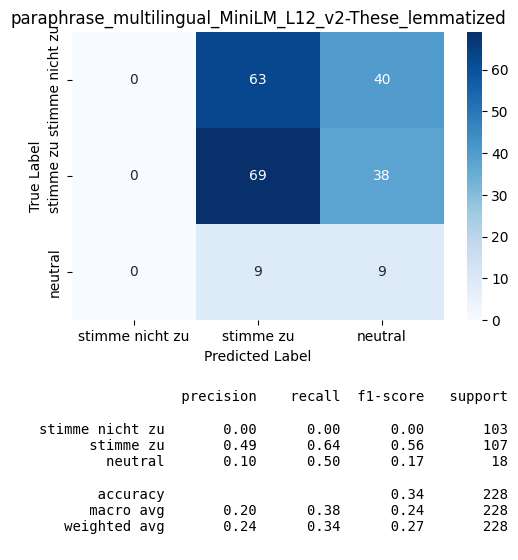

In [ ]:

party_text_columns_list = ['Text',  'Text_no_stopwords',  'Text_lemmatized']
lable_text_columns_list = ['These', 'These_no_stopwords', 'These_lemmatized']


folder_path = r'Prediction_Data\Text'

# Socres:   [accuracy, precision, recall, f1]
Model_prediction_scores = pd.DataFrame(columns= ['model', 'lable_text_column', 'party_text_column' ,'Manifesto_sorted', 'accuracy', 'precision', 'recall', 'f1'])


for idx, model in enumerate(models_list):
    tokenizer = AutoTokenizer.from_pretrained(model)
    model = AutoModel.from_pretrained(model)

    
    #
    for sort_by_state in [True, False]:
        for text_List_idx, text_column in enumerate(lable_text_columns_list):

            lable_text_column = text_column
            party_text_column = party_text_columns_list[text_List_idx]
            predicted_theses_dfs_dict, predicted_theses_df = similarity_func(all_party_textes_df,
                                                                             labled_theses_df,
                                                                             lable_text_column,
                                                                             party_text_column, 
                                                                             plot=False, 
                                                                             sort_by_classification=sort_by_state)

            folder_path_file = os.path.join(folder_path,model_names_list[idx], f'Manifesto_sorted_{sort_by_state}', text_column)
            os.makedirs(folder_path_file, exist_ok=True)

            with open(os.path.join(folder_path_file, 'predicted_theses_dfs_dict.pkl'), 'wb') as f:
                pickle.dump(predicted_theses_dfs_dict, f)

            with open(os.path.join(folder_path_file, 'predicted_theses_df.pkl'), 'wb') as f:
                pickle.dump(predicted_theses_df, f)

            #TODO Mapping des predicted theses dfs
            predicted_theses_df_mapped = mapping_similarity_to_class_func(predicted_theses_df, lable_list)

            #TODO Apply Metric to evaluate Predictions
            scores_list = prediction_metric_func(predicted_theses_df_mapped, labled_theses_df, parties_list, plot=True, plot_title=f'{model_names_list[idx]}-{text_column}')
            #TODO Save Metrics in df to compare
            Model_prediction_scores.loc[len(Model_prediction_scores)] = [model_names_list[idx], lable_text_column, party_text_column, sort_by_state ]+scores_list
            
with open(os.path.join(folder_path, 'Model_prediction_scores.pkl'), 'wb') as f:
    pickle.dump(Model_prediction_scores, f)

Neues NB:  
-> Funktion die similarity wie folgt ausgibt:    
    if label_category = party_category & sim score>=60  
        lable = stimme zu   
    elif abel_category = party_oposit_category & sim score>=60  
        lable = stimme nicht zu  
    else  
        lable = neutral  

-> Funktion die predicted Lable mit den true lable (confusion, acuraccy...)  
-> für alle modelle und Text-Kombinationen laufen lassen 
